# Primera parte TFG

## Datos

In [1]:
import json
import csv
import pandas as pd
import random
from datetime import datetime

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
sns.set_context("notebook")

plt.rcParams["font.family"] = "Times New Roman"

En primer lugar se convierte a CSV los ficheros JSON. El de business se convierte por separado ya que se filtra a sólo restaurantes.

In [2]:
input_file = "yelp_academic_dataset_business.json"
output_file = "business_restaurants.csv"

#Leer el archivo línea a línea
data = []
with open(input_file, "r", encoding="utf-8") as f:
    for line in f:
        data.append(json.loads(line))

#Pasarlo a dataframe
df= pd.DataFrame(data)

#Filtrar por categoría restaurante
df_restaurants = df[df["categories"].str.contains("Restaurants", na=False)]

#Convertir a csv
df_restaurants.to_csv(output_file, index=False, encoding="utf-8")

Después convertimos a CSV las reseñas que corresponden a restaurantes y que han sido publicadas en 2021 o 2022 que son los 2 últimos años en los que hay reseñas registradas.

In [3]:
def parse_yelp_date(s: str) -> datetime:
    #Yelp puede traer "YYYY-MM-DD" o "YYYY-MM-DD HH:MM:SS"
    try:
        return datetime.strptime(s, "%Y-%m-%d %H:%M:%S")
    except ValueError:
        return datetime.strptime(s, "%Y-%m-%d")

def jsonlines_to_csv_years_restaurants(
    review_file,
    business_file,
    output_file,
    years=(2021, 2022)
):
    business_df = pd.read_csv(business_file, usecols=["business_id"])
    business_ids = set(business_df["business_id"].astype(str))

    data = []

    with open(review_file, "r", encoding="utf-8") as f:
        for line in f:
            obj = json.loads(line)

            if obj["business_id"] not in business_ids:
                continue

            review_date = parse_yelp_date(obj["date"])
            if review_date.year in years:
                data.append(obj)

    df = pd.DataFrame(data)
    df.to_csv(output_file, index=False, encoding="utf-8")

    print(f"Archivo creado: {output_file}")
    print(f"Reseñas incluidas: {len(df)}")
    if len(df) > 0:
        print(f"Negocios únicos: {df['business_id'].nunique()}")

jsonlines_to_csv_years_restaurants(
    "yelp_academic_dataset_review.json",
    "business_restaurants.csv",
    "reviews_restaurants_2021_2022.csv",
    years=(2021, 2022)
)


Archivo creado: reviews_restaurants_2021_2022.csv
Reseñas incluidas: 429746
Negocios únicos: 31823


A continuación guardamos sólo los restaurantes tienen al menos una reseña en los últimos años (2021 y 2022).

In [4]:
business = pd.read_csv("business_restaurants.csv")

reviews = pd.read_csv(
    "reviews_restaurants_2021_2022.csv",
    usecols=["business_id"]
)

active_ids = set(reviews["business_id"].astype(str))
business["business_id"] = business["business_id"].astype(str)

business_final = business[business["business_id"].isin(active_ids)].copy()

business_final.to_csv(
    "business_final.csv",
    index=False,
    encoding="utf-8"
)

print("Archivo creado: business_final.csv")
print(f"Restaurantes iniciales: {len(business)}")
print(f"Restaurantes finales (con reseñas 2021-2022): {len(business_final)}")


Archivo creado: business_final.csv
Restaurantes iniciales: 52268
Restaurantes finales (con reseñas 2021-2022): 31823


Después, vamos a crear el CSV para checkin, de los restaurantes cuyo id esté en business_final.

In [5]:
def filter_checkins_by_business_final(
    checkin_file,
    business_final_file,
    output_file
):
    #Leer business_id válidos
    business_df = pd.read_csv(business_final_file, usecols=["business_id"])
    business_ids = set(business_df["business_id"].astype(str))

    data = []

    #Leer checkins línea a línea y filtrar
    with open(checkin_file, "r", encoding="utf-8") as f:
        for line in f:
            obj = json.loads(line)

            if obj["business_id"] in business_ids:
                data.append(obj)

    #Guardar CSV
    df = pd.DataFrame(data)
    df.to_csv(output_file, index=False, encoding="utf-8")

    print(f"Archivo creado: {output_file}")
    print(f"Check-ins incluidos: {len(df)}")
    if len(df) > 0:
        print(f"Negocios únicos con check-ins: {df['business_id'].nunique()}")

filter_checkins_by_business_final(
    "yelp_academic_dataset_checkin.json",
    "business_final.csv",
    "checkins_final.csv"
)


Archivo creado: checkins_final.csv
Check-ins incluidos: 31454
Negocios únicos con check-ins: 31454


El número de check in's incluidos coincide con el número de business_id, ya que en cada fila se almacena las reservas agregadas en un único campo (*date*).

Finalmente se crea el CSV para users, cuyo ID esté en las reseñas de 2021 y 2022.

In [6]:
def filter_users_by_reviews_years(
    users_json_file,
    reviews_2021_2022_csv,
    output_csv
):
    #Cargar user_id presentes en las reseñas 2021-2022
    rev = pd.read_csv(reviews_2021_2022_csv, usecols=["user_id"])
    user_ids = set(rev["user_id"].astype(str))

    #Leer users.json línea a línea y filtrar
    data = []
    with open(users_json_file, "r", encoding="utf-8") as f:
        for line in f:
            obj = json.loads(line)
            if obj["user_id"] in user_ids:
                data.append(obj)

    #Guardar CSV
    df = pd.DataFrame(data)
    df.to_csv(output_csv, index=False, encoding="utf-8")

    print(f"Archivo creado: {output_csv}")
    print(f"Usuarios incluidos (2021-2022): {len(df)}")
    if len(df) > 0:
        print(f"user_id únicos: {df['user_id'].nunique()}")

filter_users_by_reviews_years(
    "yelp_academic_dataset_user.json",
    "reviews_restaurants_2021_2022.csv",
    "users_2021_2022.csv"
)

Archivo creado: users_2021_2022.csv
Usuarios incluidos (2021-2022): 220854
user_id únicos: 220854


## Análisis descriptivo

Para realizar un análisis descriptivo sobre los datos ya filtrados, se crea una tabla/dataset analítico a nivel restaurante.

In [7]:
#Cargar los datos
business = pd.read_csv("business_final.csv")
reviews = pd.read_csv("reviews_restaurants_2021_2022.csv")
checkins = pd.read_csv("checkins_final.csv")

Agregamos reviews, creando las siguientes variables para cada restaurante.

In [8]:
#Agregar reviews
reviews['date'] = pd.to_datetime(reviews['date'], errors='coerce')

rev_agg = reviews.groupby('business_id').agg(
    avg_review_stars=('stars', 'mean'),
    n_reviews=('review_id', 'count'),
    sum_useful=('useful', 'sum'),
    first_review=('date', 'min'),
    last_review=('date', 'max')
).reset_index()

Agregamos el número de checkins de cada restaurante.

In [9]:
checkins['n_checkins'] = checkins['date'].fillna("").apply(
    lambda x: 0 if x == "" else len(x.split(","))
)

chk_agg = checkins[['business_id', 'n_checkins']]

Finalmente se unen todos los ficheros y con ellos se crea un dataset en formato CSV. 

In [10]:
#Se une todo
df_rest = business.merge(rev_agg, on='business_id', how='left') \
                  .merge(chk_agg, on='business_id', how='left')

df_rest['n_checkins'] = df_rest['n_checkins'].fillna(0)

#Se crea el dataset
df_rest.to_csv("dataset_restaurant_level.csv", index=False)

print("Dataset final creado")
print(f"Restaurantes: {len(df_rest)}")
print(df_rest.head())

Dataset final creado
Restaurantes: 31823
              business_id                   name              address  \
0  MTSW4McQd7CbVtyjqoe9mw     St Honore Pastries          935 Race St   
1  CF33F8-E6oudUQ46HnavjQ         Sonic Drive-In        615 S Main St   
2  bBDDEgkFA1Otx9Lfe7BZUQ         Sonic Drive-In  2312 Dickerson Pike   
3  eEOYSgkmpB90uNA7lDOMRA  Vietnamese Food Truck                  NaN   
4  il_Ro8jwPlHresjw9EGmBg                Denny's         8901 US 31 S   

           city state postal_code   latitude  longitude  stars  review_count  \
0  Philadelphia    PA       19107  39.955505 -75.155564    4.0            80   
1  Ashland City    TN       37015  36.269593 -87.058943    2.0             6   
2     Nashville    TN       37207  36.208102 -86.768170    1.5            10   
3     Tampa Bay    FL       33602  27.955269 -82.456320    4.0            10   
4  Indianapolis    IN       46227  39.637133 -86.127217    2.5            28   

   is_open                             

Ahora tenemos en cada fila la información de cada restaurante, sus características estructurales, reputación online, volumen de reseñas, engagement (useful), actividad (checkins) etc.

Por lo tanto es posible realizar el análisis descriptivo sobre los datos.

In [11]:
df_rest.info()
df_rest.describe()
df_rest.shape
df_rest.info()
df_rest.isna().sum().sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31823 entries, 0 to 31822
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   business_id       31823 non-null  object        
 1   name              31823 non-null  object        
 2   address           31625 non-null  object        
 3   city              31823 non-null  object        
 4   state             31823 non-null  object        
 5   postal_code       31821 non-null  object        
 6   latitude          31823 non-null  float64       
 7   longitude         31823 non-null  float64       
 8   stars             31823 non-null  float64       
 9   review_count      31823 non-null  int64         
 10  is_open           31823 non-null  int64         
 11  attributes        31441 non-null  object        
 12  categories        31823 non-null  object        
 13  hours             29472 non-null  object        
 14  avg_review_stars  3182

hours               2351
attributes           382
address              198
postal_code            2
business_id            0
last_review            0
first_review           0
sum_useful             0
n_reviews              0
avg_review_stars       0
categories             0
is_open                0
name                   0
review_count           0
stars                  0
longitude              0
latitude               0
state                  0
city                   0
n_checkins             0
dtype: int64

In [12]:
df_rest["business_id"].duplicated().any()

np.False_

**Resultados**:

Tamaño del dataset: 31823 restaurantes.

Número de variables: 20.
- 5 float64 → variables continuas
- 4 int64 → conteos y binaria
- 2 datetime → fechas
- 9 object → texto / categóricas

Cabe destacar 2 variables en concreto:
- *stars* → rating histórico del negocio
- *avg_review_stars* → rating medio 2021-2022
Esto es útil para ver si reputación reciente difiere de histórica, analizar la convergencia reputacional o que una sirva para predecir la otra.

Las columnas con valores faltantes son:
- *hours* → 2351
- *attributes* → 382
- *address* → 198
- *postal_code* → 2

Además, no hay duplicados en business_id, cada fila corresponde a un restaurante con un identificador único.

In [13]:
files = [
    "yelp_academic_dataset_business.json",
    "yelp_academic_dataset_checkin.json",
    "yelp_academic_dataset_review.json",
    "yelp_academic_dataset_user.json"
]

for file in files:
    with open(file, "r", encoding="utf-8") as f:
        n = sum(1 for _ in f)
    print(f"{file}: {n} registros")

yelp_academic_dataset_business.json: 150346 registros
yelp_academic_dataset_checkin.json: 131930 registros
yelp_academic_dataset_review.json: 6990280 registros
yelp_academic_dataset_user.json: 1987897 registros


## Análisis exploratorio

In [14]:
df_rest.columns

Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'attributes', 'categories', 'hours', 'avg_review_stars', 'n_reviews',
       'sum_useful', 'first_review', 'last_review', 'n_checkins'],
      dtype='object')

### Variables respuesta
- *avg_review_stars*
- *is_open*

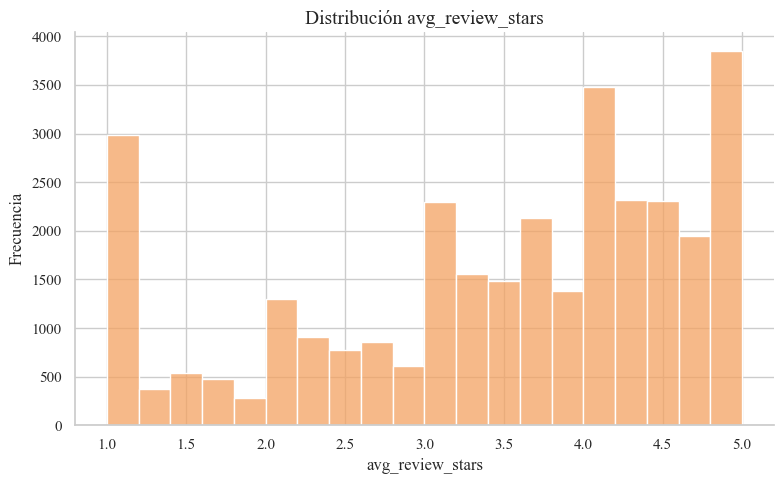

count    31823.000000
mean         3.439820
std          1.220257
min          1.000000
25%          2.666667
50%          3.750000
75%          4.400000
max          5.000000
Name: avg_review_stars, dtype: float64

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
sns.set_context("notebook")

plt.rcParams["font.family"] = "Times New Roman"

plt.figure(figsize=(8, 5))

sns.histplot(
    df_rest['avg_review_stars'],
    bins=20,
    color="#F4A261",
    edgecolor="white"
)

plt.title("Distribución avg_review_stars", fontsize=14)
plt.xlabel("avg_review_stars", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)

sns.despine()

plt.tight_layout()
plt.show()

df_rest['avg_review_stars'].describe()

Interpretación de la variable *stars*:
- **Distribución**: se concentra en valoraciones altas 4-5, aunque también hay un grupo importante en 1. No presenta normalidad.
- **Count**: cada restaurante tiene la media de valoraciones lo que confirma que esta variable es correcta para el análisis.
- **Mean**: la media es menor que la mediana, lo que significa que la distribución es ligeramente asimétrica hacia la izquierda cómo se veía en el gráfico. Esto se traduce en que hay bastantes restaurantes con valoraciones bajas.
- **Rango**: el rango de la variable es completo (1-5), la variable conserva el rango de puntuación de Yelp.

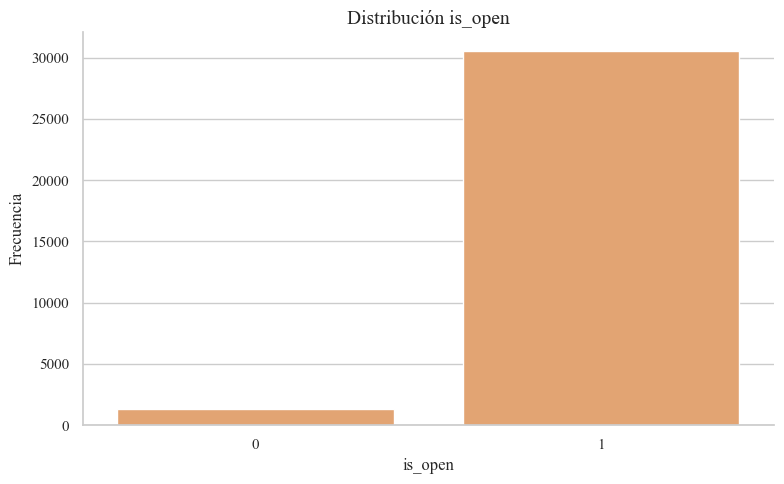

is_open
1    30529
0     1294
Name: count, dtype: int64
is_open
1    0.959338
0    0.040662
Name: proportion, dtype: float64


In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Estilo
sns.set_style("whitegrid")
sns.set_context("notebook")
plt.rcParams["font.family"] = "Times New Roman"

# Conteos
counts = df_rest['is_open'].value_counts()
percent = df_rest['is_open'].value_counts(normalize=True)

# Gráfico
plt.figure(figsize=(8, 5))

sns.countplot(
    x='is_open',
    data=df_rest,
    color="#F4A261",
    edgecolor="white"
)

# Títulos
plt.title("Distribución is_open", fontsize=14)
plt.xlabel("is_open", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)

sns.despine()

plt.tight_layout()
plt.show()

# Mostrar estadísticas
print(counts)
print(percent)

Interpretación de la variable *is_open*
- Em el gráfico se observa que la gran mayoría de restaurantes están abiertos.
- Hay un gran desbalance de clases en esta variable, por lo tanto, para evaluar los modelos no es apropiado usar *accuracy*.

### Variables numéricas

In [17]:
import numpy as np
features_num = df_rest.select_dtypes(include=[np.number])
features_num = features_num.drop(columns=['is_open'])

# Ver cuáles son
print(features_num.columns)

Index(['latitude', 'longitude', 'stars', 'review_count', 'avg_review_stars',
       'n_reviews', 'sum_useful', 'n_checkins'],
      dtype='object')


In [18]:
#Estadísticos descriptivos
df_rest[features_num.columns].describe(percentiles=[.05,.25,.5,.75,.95,.99])

,latitude,longitude,stars,review_count,avg_review_stars,n_reviews,sum_useful,n_checkins
count,31823.000000,31823.000000,31823.000000,31823.000000,31823.000000,31823.000000,31823.000000,31823.000000
mean,36.666104,-87.720854,3.560695,116.766050,3.439820,13.504258,11.110957,215.044528
std,5.770582,13.587860,0.851664,230.739792,1.220257,23.270111,25.080138,571.450401
min,27.564457,-120.083748,1.000000,5.000000,1.000000,1.000000,0.000000,0.000000
5%,27.894051,-119.686616,2.000000,7.000000,1.000000,1.000000,0.000000,3.000000
25%,32.119932,-90.205169,3.000000,20.000000,2.666667,2.000000,0.000000,18.000000
50%,38.787794,-86.019315,3.500000,50.000000,3.750000,6.000000,3.000000,64.000000
75%,39.953761,-75.390565,4.000000,126.000000,4.400000,15.000000,11.000000,209.000000
95%,43.609555,-74.995224,4.500000,421.000000,5.000000,50.000000,51.000000,870.000000
99%,53.548819,-74.803246,5.000000,968.000000,5.000000,110.780000,115.780000,2215.900000


In [19]:
import pandas as pd

# Variables numéricas
features_num = df_rest.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Variables discretas / conteos / binarias
features_discretas = []
features_continuas = []

for col in features_num:
    n_unicos = df_rest[col].nunique(dropna=True)
    
    if n_unicos <= 10:
        features_discretas.append(col)
    elif pd.api.types.is_integer_dtype(df_rest[col]):
        features_discretas.append(col)
    else:
        features_continuas.append(col)

print("Continuas:", features_continuas)
print("Discretas:", features_discretas)



Continuas: ['latitude', 'longitude', 'avg_review_stars', 'n_checkins']
Discretas: ['stars', 'review_count', 'is_open', 'n_reviews', 'sum_useful']


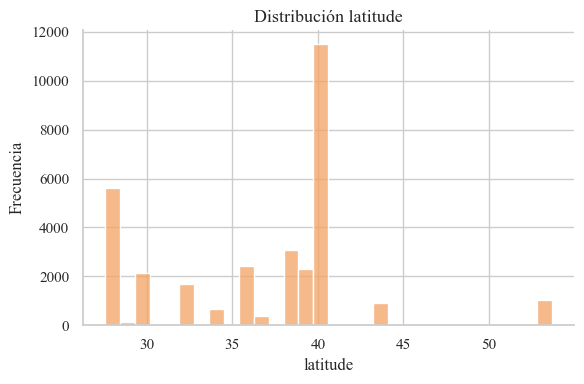

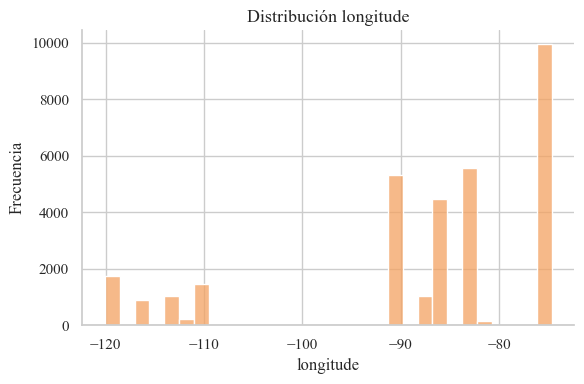

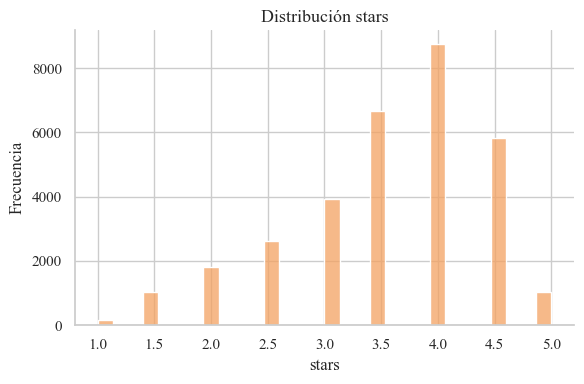

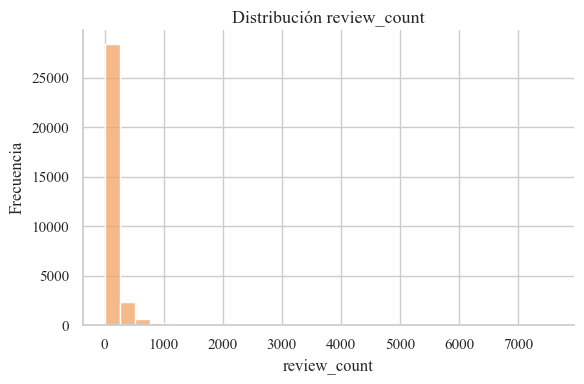

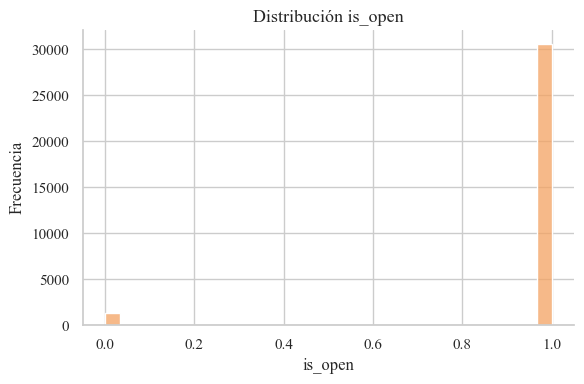

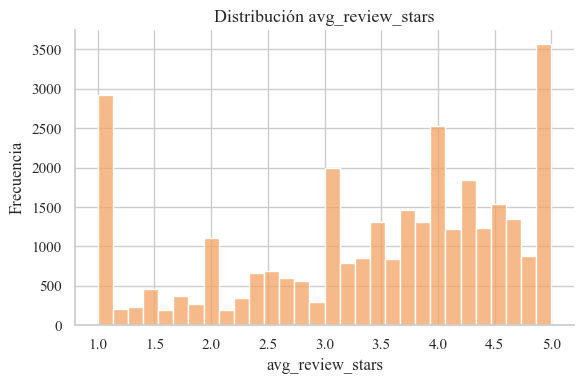

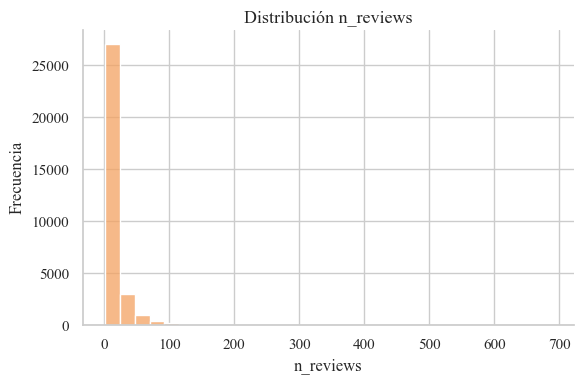

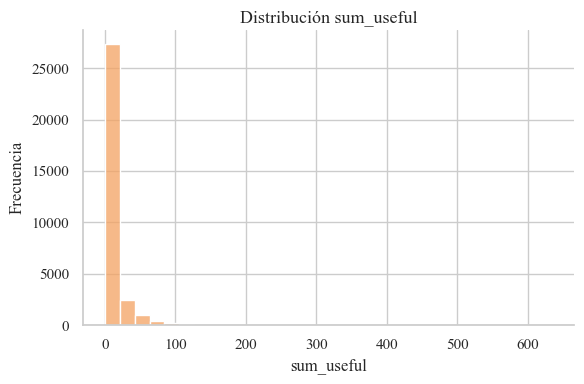

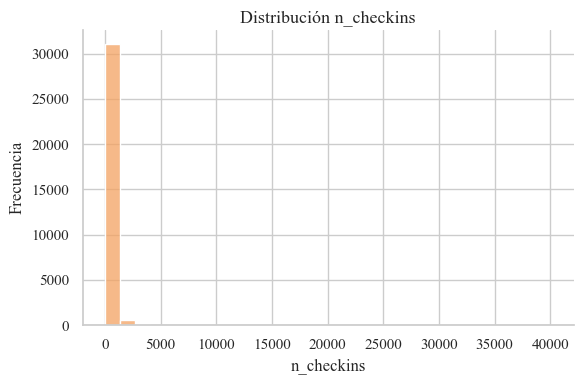

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
sns.set_context("notebook")
plt.rcParams["font.family"] = "Times New Roman"

# Asegúrate de tenerlas
features_num = df_rest.select_dtypes(include=["int64", "float64"]).columns

for col in features_num:
    plt.figure(figsize=(6,4))
    
    sns.histplot(
        df_rest[col].dropna(),
        bins=30,
        color="#F4A261",
        edgecolor="white"
    )
    
    plt.title(f"Distribución {col}", fontsize=13)
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    
    sns.despine()
    plt.tight_layout()
    plt.show()

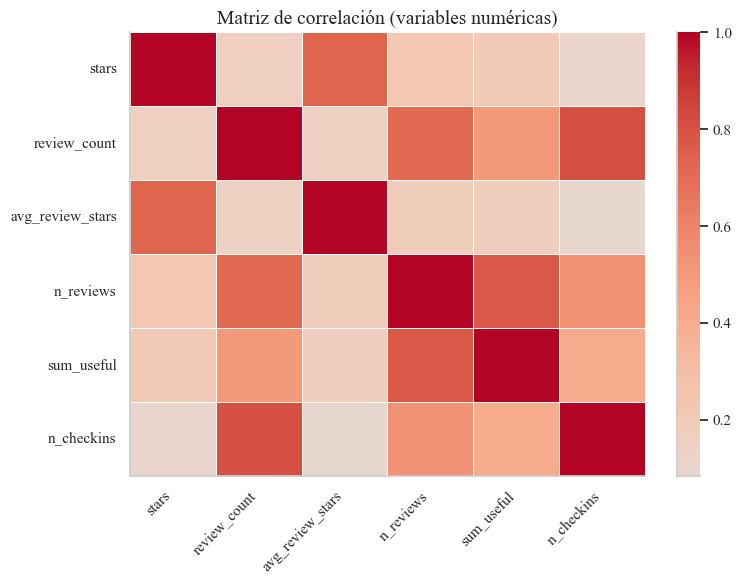

In [21]:
# Correlaciones
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
sns.set_context("notebook")
plt.rcParams["font.family"] = "Times New Roman"

# Selección de variables numéricas
features_num = df_rest.select_dtypes(include=["int64", "float64"])

# Eliminar latitud y longitud
features_num = features_num.drop(columns=["latitude", "longitude","is_open"], errors="ignore")

# Correlación
corr = features_num.corr()

# Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=False,
    linewidths=0.5,
    linecolor="white"
)

plt.title("Matriz de correlación (variables numéricas)", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

sns.despine()
plt.tight_layout()
plt.show()

### Variables categóricas

Para el análisis de variables categoricas nos centramos en las que no son únicas por restaurante (*business_id*, *name*, *address*), que son *city* y *state*. *postal_code* es repetitivo.

- *State*:

In [22]:
df_rest['state'].value_counts()
df_rest.groupby('state')['avg_review_stars'].mean().sort_values()

state
IL    3.116261
AZ    3.322073
NJ    3.347881
MO    3.358999
TN    3.381570
NV    3.387451
IN    3.402286
DE    3.403446
ID    3.406691
FL    3.452386
PA    3.491237
LA    3.559459
AB    3.663937
CA    3.810219
Name: avg_review_stars, dtype: float64

In [23]:
df_rest.groupby('state')['is_open'].mean().sort_values()

state
CA    0.938346
MO    0.948454
LA    0.949396
NV    0.950789
FL    0.955342
PA    0.958680
IN    0.958751
ID    0.960133
AZ    0.961697
TN    0.965050
IL    0.970126
NJ    0.974118
DE    0.981605
AB    0.987366
Name: is_open, dtype: float64

In [24]:
df_rest.groupby('state').agg(
    n=('business_id','size'),
    mean_stars=('avg_review_stars','mean')
).sort_values('n', ascending=False)

,n,mean_stars
state,,
PA,7212,3.491237
FL,5710,3.452386
TN,2804,3.381570
IN,2691,3.402286
MO,2522,3.358999
LA,2154,3.559459
NJ,2125,3.347881
AZ,1697,3.322073
NV,1077,3.387451


Se observa que hay diferencias relevantes en cuánto a la valoración media de los restaurantes por Estado, es decir estas diferencias son estructurales y afectan al análisis.

Por otra parte vemos que en todos los estados la variable *is_open* está desbalanceada cómo veíamos anteriormente. 

También, se obtiene el tamaño de cada Estado, es decir, el número de restaurantes por Estado. Los Estados con mayor número de restaurantes (PA, FL, TN, IN, MO, LA, NJ) presentan diferencias moderadas entre la valoración media de sus restaurantes. Mientras que, las diferencias más extremas aparecen en estados medianos.

Para contrastar formalmente si la diferencia entre las valoraciones medias es significativa se realiza el test ANOVA:

In [25]:
from scipy.stats import f_oneway

groups = [group['avg_review_stars'].values 
          for name, group in df_rest.groupby('state')]

f_stat, p_value = f_oneway(*groups)

print("F:", f_stat)
print("p-value:", p_value)

F: 17.490632064213482
p-value: 4.4990819412663576e-41


**Resultado**:
A un nivel de significación del 5%, hay evidencias estadísticas suficientes para rechazar la hipótesis nula de igualdad de medias, es decir, la variable *state* aporta información al análisis.

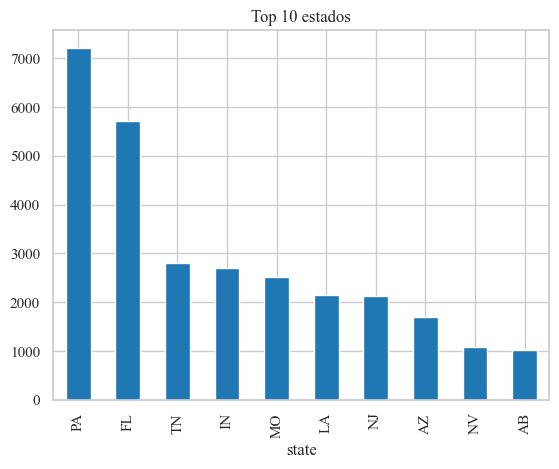

In [26]:
#Estado
df_rest['state'].value_counts().head(10)
df_rest['state'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 estados")
plt.show()

- *City*:

In [27]:
df_rest['city'].nunique()

816

In [28]:
df_rest['city'].value_counts().head(20)

city
Philadelphia        3077
Tampa               1852
Indianapolis        1799
Nashville           1549
Tucson              1541
New Orleans         1293
Edmonton             912
Saint Louis          857
Reno                 798
Boise                570
Santa Barbara        439
Clearwater           434
St. Louis            404
Wilmington           371
Metairie             329
Saint Petersburg     292
Franklin             291
St. Petersburg       250
Sparks               242
Meridian             228
Name: count, dtype: int64

Al representar los valores únicos de la variable *city* se observa que es necesario normalizar el texto, ya que las mismas ciudades aparecen escritas de diversas formas.

In [29]:
df_rest['city_clean'] = (
    df_rest['city']
    .str.strip()
    .str.lower()
    .str.replace(r'\s+', ' ', regex=True)
)
df_rest[df_rest['city_clean'].str.contains("louis", na=False)]['city_clean'].unique()
print("Original:", df_rest['city'].nunique())
print("Limpia:", df_rest['city_clean'].nunique())

Original: 816
Limpia: 752


In [30]:
df_rest['city_clean'].value_counts().head(20)

city_clean
philadelphia        3079
tampa               1859
indianapolis        1800
nashville           1552
tucson              1543
new orleans         1294
edmonton             914
saint louis          857
reno                 800
boise                570
santa barbara        440
clearwater           435
st. louis            405
wilmington           373
metairie             329
saint petersburg     292
franklin             291
st. petersburg       251
sparks               242
meridian             229
Name: count, dtype: int64

Como con la limpieza básica (eliminar mayúsculas/minúsculas incosistentes, espacios duplicados y variaciones trivales) no reduce el número de valores únicos lo suficiente, para comprobar que se puede incluir esta variable en el análisis vemos el nº de restaurantes por ciudad.

Las ciudades Philadelphia, Tampa, Indianapolis, Nashville, Tucson y New Orleans albergan el 35% de los restaurantes del dataset (casi 11.000), por lo tanto, la variable *city* también tiene peso estructural y debe incluirse en el modelo. Para ello voy a agrupar en top 15 ciudades (no más para evitar incluir ruido).

In [31]:
#Agrupación
top_cities = df_rest['city_clean'].value_counts().head(15).index

df_rest['city_grouped'] = df_rest['city_clean'].apply(
    lambda x: x if x in top_cities else "other"
)

df_rest['city_grouped'] = df_rest['city_grouped'].replace({
    'st. louis': 'saint louis',
    'st. petersburg': 'saint petersburg'
})

#Validación
df_rest['city_grouped'].value_counts(normalize=True)

city_grouped
other            0.489363
philadelphia     0.096754
tampa            0.058417
indianapolis     0.056563
nashville        0.048770
tucson           0.048487
new orleans      0.040662
saint louis      0.039657
edmonton         0.028721
reno             0.025139
boise            0.017912
santa barbara    0.013826
clearwater       0.013669
wilmington       0.011721
metairie         0.010338
Name: proportion, dtype: float64

Ahora hemos reducido la dimensionalidad, evitando el sobreajuste/*overfitting* y creando una variable apta para one-hot encoding (codificación que se usará más adelante).

In [32]:
df_rest.groupby('city_grouped').agg(
    n=('business_id','size'),
    mean_stars=('avg_review_stars','mean'),
).sort_values('mean_stars')

,n,mean_stars
city_grouped,,
metairie,329,3.236963
tucson,1543,3.328719
other,15573,3.365109
reno,800,3.429433
indianapolis,1800,3.438280
wilmington,373,3.440849
tampa,1859,3.449160
boise,570,3.473039
clearwater,435,3.479845


In [33]:
df_rest.groupby('city_grouped').agg(
    n=('business_id','size'),
    prop_open=('is_open','mean')
).sort_values('prop_open')

,n,prop_open
city_grouped,,
santa barbara,440,0.934091
saint louis,1262,0.938986
new orleans,1294,0.940495
philadelphia,3079,0.949984
reno,800,0.951250
indianapolis,1800,0.955000
tampa,1859,0.955352
boise,570,0.956140
clearwater,435,0.956322


En el análisis bivariante de las *city_grouped* y las variables respuesta se obtiene una conclusión similar que con *state*. Finalmente comprobamos con ANOVA si la diferencia entre ciudades es relevante para nuestro análisis.

In [34]:
from scipy.stats import f_oneway

groups = [group['avg_review_stars'].values
          for name, group in df_rest.groupby('city_grouped')]

f_stat, p_value = f_oneway(*groups)

print("F:", f_stat)
print("p-value:", p_value)

F: 20.945553349402182
p-value: 5.629073218343285e-54


**Resultado**:

A un nivel de significación del 5%, hay evidencias suficientes para rechazar la hipótesis nula de igualdada de medias. Es decir, la variable *city_grouped* aporta información a nuestro análisis. Además se observa que el efecto de esta variable es mayor que la anterior, ya que el estadístico F es mayor. Por lo tanto hay mayor diferencia de valoraciones según la ciudad.

También vamos a analizar las variables categóricas complejas:
- *categories*: variable multietiqueta, con valores separados por comas.
- *atributes*: diccionario de texto.
- *hours*
- *first_review*
- *last_review*

- *Categories*

In [35]:
from collections import Counter

all_categories = df_rest['categories'].dropna().str.split(', ')
flat = [item for sublist in all_categories for item in sublist]

len(set(flat))  # número real de categorías individuales

660

In [36]:
Counter(flat).most_common(30)

[('Restaurants', 31823),
 ('Food', 9778),
 ('Nightlife', 5552),
 ('Sandwiches', 5426),
 ('Bars', 5360),
 ('American (Traditional)', 5255),
 ('Fast Food', 4803),
 ('Pizza', 4579),
 ('Breakfast & Brunch', 4241),
 ('Burgers', 3975),
 ('American (New)', 3466),
 ('Mexican', 3159),
 ('Italian', 2803),
 ('Coffee & Tea', 2670),
 ('Seafood', 2428),
 ('Salad', 2182),
 ('Chicken Wings', 2128),
 ('Event Planning & Services', 2021),
 ('Chinese', 2007),
 ('Cafes', 1563),
 ('Delis', 1464),
 ('Caterers', 1350),
 ('Desserts', 1260),
 ('Bakeries', 1215),
 ('Specialty Food', 1206),
 ('Sports Bars', 1192),
 ('Japanese', 1161),
 ('Sushi Bars', 1113),
 ('Cocktail Bars', 1052),
 ('Steakhouses', 1013)]

In [37]:
#Las top 14 categorías sin contar restaurants ni food que la tienen todas
top_categories = [
    'Nightlife',
    'Sandwiches',
    'Bars',
    'American (Traditional)',
    'Fast Food',
    'Pizza',
    'Breakfast & Brunch',
    'Burgers',
    'American (New)',
    'Mexican',
    'Italian',
    'Coffee & Tea',
    'Seafood',
    'Salad'
]

for cat in top_categories:
    safe_name = cat.replace(" ", "_").replace("(", "").replace(")", "")
    df_rest[f'cat_{safe_name}'] = df_rest['categories'].str.contains(
        cat,
        regex=False,
        na=False
    ).astype(int)

De esta forma evitamos tener un número exageradamente alto de categorías, y eliminamos el riesgo de *overfitting*.

In [38]:
cat_cols = [col for col in df_rest.columns if col.startswith('cat_')]

results_stars = []

for col in cat_cols:
    mean_with = df_rest[df_rest[col] == 1]['avg_review_stars'].mean()
    mean_without = df_rest[df_rest[col] == 0]['avg_review_stars'].mean()
    results_stars.append((col, mean_with, mean_without, mean_with - mean_without))

results_stars_df = pd.DataFrame(
    results_stars,
    columns=['category', 'mean_with', 'mean_without', 'difference']
).sort_values('difference', ascending=False)

results_stars_df

,category,mean_with,mean_without,difference
2,cat_Bars,3.685649,3.369772,0.315877
12,cat_Seafood,3.669581,3.420613,0.248968
0,cat_Nightlife,3.642345,3.397019,0.245326
8,cat_American_New,3.598787,3.420390,0.178397
10,cat_Italian,3.538010,3.430336,0.107674
13,cat_Salad,3.528756,3.433273,0.095483
6,cat_Breakfast_&_Brunch,3.507899,3.429352,0.078547
9,cat_Mexican,3.385659,3.445812,-0.060153
3,cat_American_Traditional,3.368653,3.453896,-0.085244
1,cat_Sandwiches,3.364640,3.455273,-0.090633


In [39]:
results_open = []

for col in cat_cols:
    prop_with = df_rest[df_rest[col] == 1]['is_open'].mean()
    prop_without = df_rest[df_rest[col] == 0]['is_open'].mean()
    results_open.append((col, prop_with, prop_without, prop_with - prop_without))

results_open_df = pd.DataFrame(
    results_open,
    columns=['category', 'prop_open_with', 'prop_open_without', 'difference']
).sort_values('difference')

results_open_df

,category,prop_open_with,prop_open_without,difference
8,cat_American_New,0.944893,0.961103,-0.016210
12,cat_Seafood,0.948676,0.960229,-0.011553
0,cat_Nightlife,0.951369,0.961022,-0.009653
2,cat_Bars,0.952671,0.961237,-0.008566
6,cat_Breakfast_&_Brunch,0.952134,0.960445,-0.008311
3,cat_American_Traditional,0.955281,0.960140,-0.004859
13,cat_Salad,0.958295,0.959414,-0.001119
1,cat_Sandwiches,0.961113,0.958973,0.002141
10,cat_Italian,0.961470,0.959132,0.002338
9,cat_Mexican,0.962145,0.959027,0.003118


Con estos resultados se ve las categorías a las que pertenecen los restaurantes que tienen en promedio, una valoración reciente más alta o más baja que los que no pertenecen.

Pero hay que tener en cuenta que estas diferencias son bivariantes “crudas”. No implican causalidad y están muy afectadas por mezcla de tipos de negocio (ej: fast food) y por co-ocurrencia de categorías (un mismo negocio puede ser Bars + Nightlife + Food).

También se ve la proporción de negocios abiertos, dónde la diferencia no parece significativa.

En resumen, tras codificar las categorías como variables binarias, el análisis bivariante sugiere que el tipo de establecimiento está más relacionado con la reputación que con la supervivencia.

Categorías como Bars, Nightlife o Seafood presentan medias de avg_review_stars superiores a las de restaurantes sin dichas etiquetas, mientras que Fast Food y Burgers muestran medias considerablemente inferiores.

En cambio, las diferencias en is_open por categoría son reducidas (pocos puntos porcentuales), lo que indica que la categoría influye menos en la probabilidad de permanencia activa.

In [40]:
#Verificar el efecto
cat_cols = [c for c in df_rest.columns if c.startswith("cat_")]
df_rest[cat_cols].sum().sort_values(ascending=False)
df_rest[df_rest["cat_Fast_Food"]==1]["avg_review_stars"].describe()
df_rest["cat_Fast_Food"].sum()

np.int64(4803)

In [41]:
df_rest[df_rest["cat_Fast_Food"]==1]["avg_review_stars"].describe()
cols = ["cat_Fast_Food","cat_Burgers","cat_Pizza","cat_Sandwiches","cat_Coffee_&_Tea"]
df_rest[df_rest["cat_Fast_Food"]==1][cols].mean().sort_values(ascending=False)

cat_Fast_Food       1.000000
cat_Burgers         0.435145
cat_Sandwiches      0.194254
cat_Coffee_&_Tea    0.133875
cat_Pizza           0.057464
dtype: float64

In [42]:
df_rest[df_rest["cat_Fast_Food"]==1]["avg_review_stars"].describe()

count    4803.00000
mean        2.26805
std         1.27511
min         1.00000
25%         1.00000
50%         2.00000
75%         3.00000
max         5.00000
Name: avg_review_stars, dtype: float64

El efecto de la categoría Fast Food no se debe a un tamaño muestral pequeño (4803 observaciones). La diferencia negativa en avg_review_stars para Fast Food es robusta en términos descriptivos.

También se tiene en cuenta que Fast food está muy solapado a Burguers y a Sandwiches, es decir que el efecto está capturando un perfil de negocio: precios bajos, alta rotación, servicio rápido etc. Además de que Burguers y Sandwiches también tienen un efcto positivo, por lo tanto está captando un patrón estructural.

Esto se confirma observando su distribución, que está desplazada hacia abajo (Q1:1, Q3:3) Eso significa que la mayoría de restaurantes Fast Food están sistemáticamente peor valorados y la diferencia de −1.38 respecto al resto no viene de unos pocos casos extremos.

La categoría Fast Food presenta una media de 2.27 estrellas, con mediana 2.0, significativamente inferior a la media global del dataset (3.44)

El modelo de negocio influye mucho en la reputación online.

- *Atributes*:

In [43]:
df_rest['attributes'].dropna().iloc[0]
df_rest['attributes'].dropna().iloc[10]
df_rest['attributes'].dropna().iloc[50]

'{\'OutdoorSeating\': \'False\', \'Alcohol\': "\'full_bar\'", \'Smoking\': "u\'no\'", \'GoodForMeal\': "{\'dessert\': False, \'latenight\': False, \'lunch\': True, \'dinner\': False, \'brunch\': True, \'breakfast\': True}", \'WiFi\': "\'no\'", \'RestaurantsReservations\': \'False\', \'RestaurantsAttire\': "\'casual\'", \'BusinessParking\': "{\'garage\': None, \'street\': False, \'validated\': None, \'lot\': False, \'valet\': False}", \'RestaurantsPriceRange2\': \'2\', \'HasTV\': \'True\', \'HappyHour\': \'False\', \'BikeParking\': \'False\', \'CoatCheck\': \'False\', \'GoodForKids\': \'True\', \'BusinessAcceptsCreditCards\': \'True\', \'RestaurantsGoodForGroups\': \'False\', \'RestaurantsDelivery\': \'False\', \'RestaurantsTakeOut\': \'True\', \'GoodForDancing\': \'False\', \'Ambience\': "{u\'divey\': False, u\'hipster\': False, u\'casual\': None, u\'touristy\': None, u\'trendy\': None, u\'intimate\': None, u\'romantic\': None, u\'classy\': False, u\'upscale\': None}", \'Music\': "{\'d

*Atributes* es una variable diccionario serializado como string, y además contiene diccionarios anidados también como strings.

Para trabajar con esta variable se debe hacer *Parsing*, que consiste en convertir un texto estructurado en un objeto que el programa pueda entender y manipular.

Para ello necesitamos ROBUSTEZ:

Dado que la variable attributes se encuentra serializada como texto y contiene estructuras anidadas heterogéneas, se aplicó un proceso de parsing robusto mediante ast.literal_eval, incorporando control de excepciones para garantizar estabilidad y correcta conversión a estructuras diccionario.

In [44]:
from pandas import json_normalize

attr_df = json_normalize(df['attributes'].fillna({}))
attr_df.shape

(150346, 39)

In [45]:
attr_df.isna().mean().sort_values(ascending=False).head(30)

RestaurantsCounterService    0.999874
DietaryRestrictions          0.999794
Open24Hours                  0.999741
AgesAllowed                  0.999142
HairSpecializesIn            0.992916
BYOBCorkage                  0.990395
Corkage                      0.976368
BYOB                         0.970395
Smoking                      0.969623
GoodForDancing               0.969218
CoatCheck                    0.962859
BestNights                   0.962127
AcceptsInsurance             0.962001
Music                        0.949975
DriveThru                    0.948386
HappyHour                    0.899093
BusinessAcceptsBitcoin       0.884067
DogsAllowed                  0.878387
RestaurantsTableService      0.867093
WheelchairAccessible         0.807424
GoodForMeal                  0.806533
NoiseLevel                   0.747296
RestaurantsAttire            0.738902
Caters                       0.733102
ByAppointmentOnly            0.718390
Alcohol                      0.712736
RestaurantsG

In [46]:
import numpy as np

def to_bool(x):
    if x in ['True', True]: return True
    if x in ['False', False]: return False
    return np.nan

bool_cols = [c for c in attr_df.columns if attr_df[c].dropna().isin(['True','False',True,False]).all()]
for c in bool_cols:
    attr_df[c] = attr_df[c].map(to_bool)

In [47]:
na_ratio = attr_df.isna().mean()
cols_to_drop = na_ratio[na_ratio > 0.95].index
attr_df = attr_df.drop(columns=cols_to_drop)

attr_df.shape

(150346, 26)

In [48]:
attr_df.isna().mean().sort_values(ascending=False)

Music                         0.949975
DriveThru                     0.948386
HappyHour                     0.899093
BusinessAcceptsBitcoin        0.884067
DogsAllowed                   0.878387
RestaurantsTableService       0.867093
WheelchairAccessible          0.807424
GoodForMeal                   0.806533
NoiseLevel                    0.747296
RestaurantsAttire             0.738902
Caters                        0.733102
ByAppointmentOnly             0.718390
Alcohol                       0.712736
RestaurantsGoodForGroups      0.706211
Ambience                      0.705486
HasTV                         0.700132
RestaurantsReservations       0.699048
OutdoorSeating                0.675402
GoodForKids                   0.644986
RestaurantsDelivery           0.625650
WiFi                          0.621447
RestaurantsTakeOut            0.601872
BikeParking                   0.516861
RestaurantsPriceRange2        0.432549
BusinessParking               0.394164
BusinessAcceptsCreditCard

In [49]:
# Calcular proporción de NA
na_ratio = attr_df.isna().mean()

# Seleccionar columnas con más del 60% de NA
cols_to_drop = na_ratio[na_ratio > 0.60].index

# Eliminar columnas
attr_df = attr_df.drop(columns=cols_to_drop)

# Ver nueva dimensión
attr_df.shape

(150346, 4)

In [50]:
attr_df.columns

Index(['BusinessAcceptsCreditCards', 'BikeParking', 'RestaurantsPriceRange2',
       'BusinessParking'],
      dtype='object')

In [51]:
import pandas as pd

def to_bool(x):
    if pd.isna(x):
        return pd.NA
    if isinstance(x, bool):
        return x
    if isinstance(x, str):
        x = x.strip().lower()
        if x == "true": return True
        if x == "false": return False
    return pd.NA

attr_df["BusinessAcceptsCreditCards"] = (
    attr_df["BusinessAcceptsCreditCards"]
    .map(to_bool)
    .astype("boolean")
)

attr_df["BikeParking"] = (
    attr_df["BikeParking"]
    .map(to_bool)
    .astype("boolean")
)

attr_df["RestaurantsPriceRange2"] = pd.to_numeric(
    attr_df["RestaurantsPriceRange2"],
    errors="coerce"
)

In [52]:
from pandas import json_normalize

parking_df = json_normalize(attr_df["BusinessParking"])
parking_df = parking_df.add_prefix("BusinessParking_")

attr_df = attr_df.drop(columns=["BusinessParking"]).join(parking_df)

In [53]:
print('business_id' in df_rest.columns)
print('business_id' in attr_df.columns)

True
False


In [54]:
print(df_rest.index[:5])
print(attr_df.index[:5])

RangeIndex(start=0, stop=5, step=1)
RangeIndex(start=0, stop=5, step=1)


In [55]:
attr_df['business_id'] = df['business_id']
df_rest = df_rest.merge(attr_df, on='business_id', how='left')

In [56]:
df_rest.columns

Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'attributes', 'categories', 'hours', 'avg_review_stars', 'n_reviews',
       'sum_useful', 'first_review', 'last_review', 'n_checkins', 'city_clean',
       'city_grouped', 'cat_Nightlife', 'cat_Sandwiches', 'cat_Bars',
       'cat_American_Traditional', 'cat_Fast_Food', 'cat_Pizza',
       'cat_Breakfast_&_Brunch', 'cat_Burgers', 'cat_American_New',
       'cat_Mexican', 'cat_Italian', 'cat_Coffee_&_Tea', 'cat_Seafood',
       'cat_Salad', 'BusinessAcceptsCreditCards', 'BikeParking',
       'RestaurantsPriceRange2'],
      dtype='object')

**Explicación**: se ha trabajado el bloque *attributes* con el objetivo de transformarlo en variables utilizables para el análisis posterior.

Primero, se expandió el diccionario contenido en *attributes* en columnas independientes mediante normalización. Esto permitió convertir la información anidada en variables estructuradas.

Posteriormente, se realizó un análisis de valores ausentes y se eliminaron aquellas variables con más del 60% de datos faltantes, ya que su baja representatividad podría introducir ruido y reducir la capacidad explicativa del modelo. Tras este filtrado, se conservaron cuatro variables relevantes:

- BusinessAcceptsCreditCards
- BikeParking
- RestaurantsPriceRange2
- BusinessParking

A continuación:

Se convirtieron las variables booleanas (BusinessAcceptsCreditCards, BikeParking) a tipo booleano real.

Se transformó RestaurantsPriceRange2 a formato numérico.

Se desanidó la variable BusinessParking, generando columnas independientes para cada tipo de estacionamiento.

En esta etapa no se realizó imputación de valores faltantes, ya que esta operación se llevará a cabo posteriormente dentro del proceso de preprocesamiento tras la división en entrenamiento y test (holdout), evitando así fuga de información.

- *Hours*:

In [57]:
df_rest['hours'].notna().mean()

np.float64(0.9261226157181912)

In [58]:
#Expandir diccionario
hours_df = json_normalize(df["hours"])

Se crean variables útiles:

In [59]:
#Nº de días que abren
df["open_days_count"] = hours_df.notna().sum(axis=1)

#Fin de semana
df["open_weekend"] = (
    hours_df[["Saturday", "Sunday"]]
    .notna()
    .any(axis=1)
)

#Todos los días
df["open_7_days"] = (df["open_days_count"] == 7)

#Añadirlas a df_rest
df_rest = df_rest.join(df[["open_days_count", "open_weekend", "open_7_days"]])

In [60]:
df_rest.columns

Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'attributes', 'categories', 'hours', 'avg_review_stars', 'n_reviews',
       'sum_useful', 'first_review', 'last_review', 'n_checkins', 'city_clean',
       'city_grouped', 'cat_Nightlife', 'cat_Sandwiches', 'cat_Bars',
       'cat_American_Traditional', 'cat_Fast_Food', 'cat_Pizza',
       'cat_Breakfast_&_Brunch', 'cat_Burgers', 'cat_American_New',
       'cat_Mexican', 'cat_Italian', 'cat_Coffee_&_Tea', 'cat_Seafood',
       'cat_Salad', 'BusinessAcceptsCreditCards', 'BikeParking',
       'RestaurantsPriceRange2', 'open_days_count', 'open_weekend',
       'open_7_days'],
      dtype='object')

- *First_review* y *last_review*

In [61]:
print(rev_agg.columns)

Index(['business_id', 'avg_review_stars', 'n_reviews', 'sum_useful',
       'first_review', 'last_review'],
      dtype='object')


In [62]:
df_rest = df_rest.drop(columns=["first_review", "last_review"], errors="ignore")

df_rest["business_id"] = df_rest["business_id"].astype(str)
rev_agg["business_id"] = rev_agg["business_id"].astype(str)

df_rest = df_rest.merge(
    rev_agg[["business_id", "first_review", "last_review"]],
    on="business_id",
    how="left",
    validate="m:1"
)

df_rest["first_review"] = pd.to_datetime(df_rest["first_review"], errors="coerce")
df_rest["last_review"] = pd.to_datetime(df_rest["last_review"], errors="coerce")

In [63]:
df_rest["first_review"].min(), df_rest["first_review"].max()
df_rest["last_review"].min(), df_rest["last_review"].max()

(Timestamp('2021-01-01 00:00:40'), Timestamp('2022-01-19 19:48:25'))

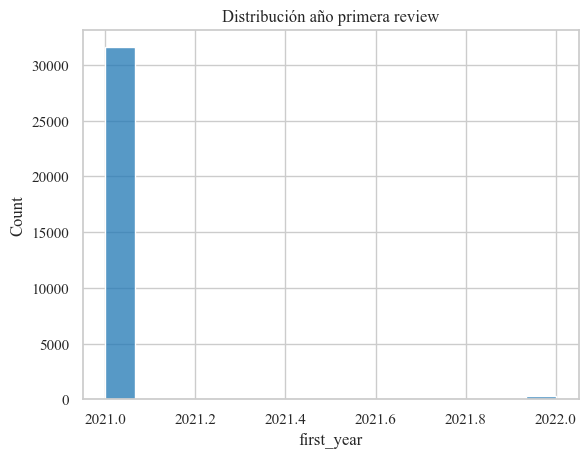

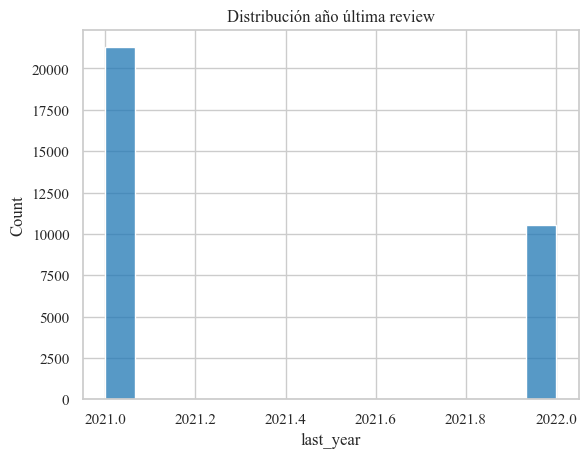

In [64]:
df_rest["first_year"] = df_rest["first_review"].dt.year
df_rest["last_year"] = df_rest["last_review"].dt.year

df_rest["first_year"].value_counts().sort_index()
df_rest["last_year"].value_counts().sort_index()

import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df_rest["first_year"], bins=15)
plt.title("Distribución año primera review")
plt.show()

sns.histplot(df_rest["last_year"], bins=15)
plt.title("Distribución año última review")
plt.show()

In [65]:
#Crear variable
df_rest["review_days"] = (
    df_rest["last_review"] - df_rest["first_review"]
).dt.days

In [66]:
df_rest["review_days"].describe()

count    31823.000000
mean       221.130095
std        131.739516
min          0.000000
25%        111.000000
50%        260.000000
75%        338.000000
max        383.000000
Name: review_days, dtype: float64

La variable de longevidad en días de las reseñas de cada restaurante tiene una ligera asimetría a la izquierda (mediana > media).
Para regresiones etc. Dejo la variable continua *review_days*, mientras que para reglas de decisión voy a crear variables binarias (dummy) *trayectoria_*.

In [67]:
#Creo variables (con el 25% más o menos de los restaurantes en cada uno)
df_rest["review_days_group"] = pd.qcut(
    df_rest["review_days"],
    q=4,
    labels=[
        "trayectoria_baja",
        "trayectoria_media_baja",
        "trayectoria_media_alta",
        "trayectoria_alta"
    ]
)

review_dummies = pd.get_dummies(
    df_rest["review_days_group"],
    prefix="trayectoria"
)

df_rest = pd.concat([df_rest, review_dummies], axis=1)

In [68]:
df_rest.columns

Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'attributes', 'categories', 'hours', 'avg_review_stars', 'n_reviews',
       'sum_useful', 'n_checkins', 'city_clean', 'city_grouped',
       'cat_Nightlife', 'cat_Sandwiches', 'cat_Bars',
       'cat_American_Traditional', 'cat_Fast_Food', 'cat_Pizza',
       'cat_Breakfast_&_Brunch', 'cat_Burgers', 'cat_American_New',
       'cat_Mexican', 'cat_Italian', 'cat_Coffee_&_Tea', 'cat_Seafood',
       'cat_Salad', 'BusinessAcceptsCreditCards', 'BikeParking',
       'RestaurantsPriceRange2', 'open_days_count', 'open_weekend',
       'open_7_days', 'first_review', 'last_review', 'first_year', 'last_year',
       'review_days', 'review_days_group', 'trayectoria_trayectoria_baja',
       'trayectoria_trayectoria_media_baja',
       'trayectoria_trayectoria_media_alta', 'trayectoria_trayectoria_alta'],
      dtype='object')

### Análisis bivariante

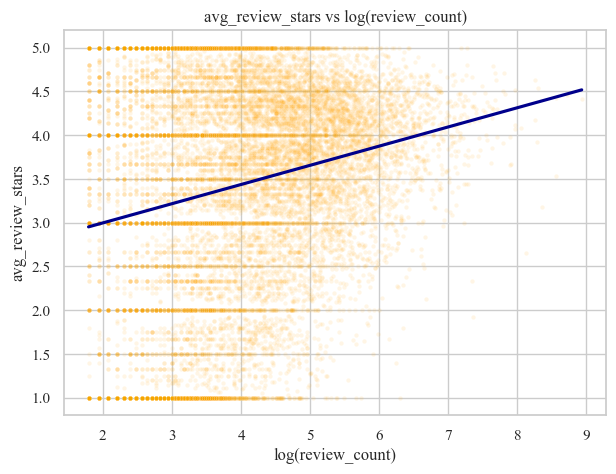

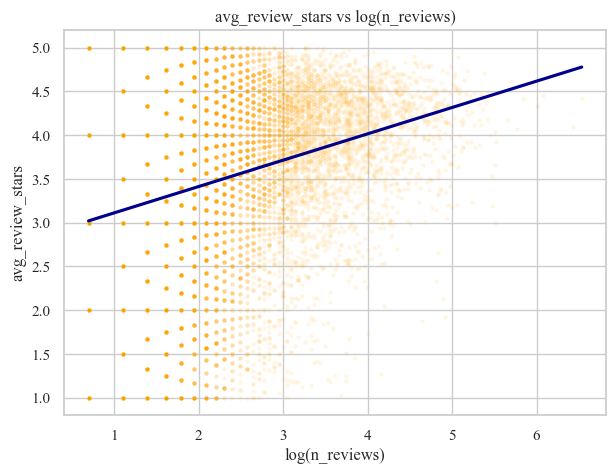

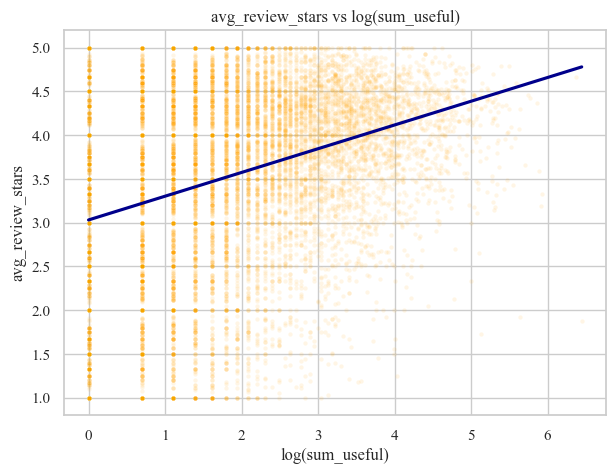

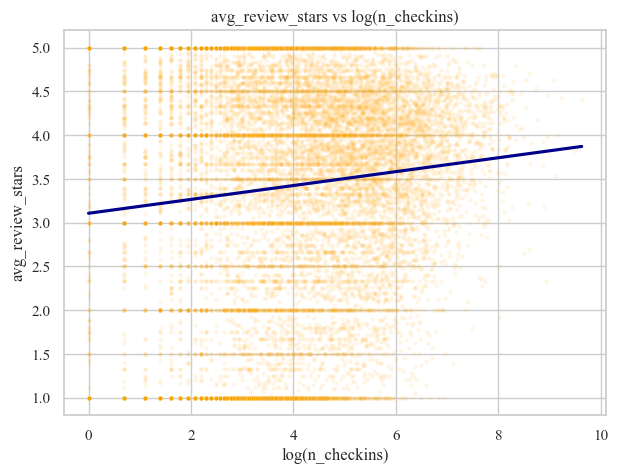

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

target = "avg_review_stars"
vars_actividad = ["review_count", "n_reviews", "sum_useful", "n_checkins"]

for var in vars_actividad:
    if var in df_rest.columns:
        
        temp = df_rest[[var, target]].dropna().sample(15000, random_state=42).copy()
        temp[f"log_{var}"] = np.log1p(temp[var])
        
        plt.figure(figsize=(7,5))
        
        sns.scatterplot(
            data=temp,
            x=f"log_{var}",
            y=target,
            alpha=0.1,
            s=10,
            color="orange"
        )
        
        sns.regplot(
            data=temp,
            x=f"log_{var}",
            y=target,
            scatter=False,
            ci=None,
            color="darkblue"
        )
        
        plt.title(f"{target} vs log({var})")
        plt.xlabel(f"log({var})")
        plt.ylabel(target)
        
        plt.show()

In [70]:
from scipy.stats import kruskal

cat_vars = [col for col in df_rest.columns if col.startswith("cat_")]

results_cat = []

for var in cat_vars:
    temp = df_rest[[var, target]].dropna()
    
    mean_1 = temp[temp[var] == 1][target].mean()
    mean_0 = temp[temp[var] == 0][target].mean()
    
    stat, pvalue = kruskal(
        temp[temp[var] == 1][target],
        temp[temp[var] == 0][target]
    )
    
    results_cat.append({
        "categoria": var,
        "media_con": mean_1,
        "media_sin": mean_0,
        "diferencia": mean_1 - mean_0,
        "pvalue": pvalue
    })

results_cat_df = pd.DataFrame(results_cat).sort_values("diferencia", ascending=False)
print(results_cat_df)

                   categoria  media_con  media_sin  diferencia         pvalue
2                   cat_Bars   3.685649   3.369772    0.315877   3.308424e-40
12               cat_Seafood   3.669581   3.420613    0.248968   2.673608e-09
0              cat_Nightlife   3.642345   3.397019    0.245326   2.414841e-15
8           cat_American_New   3.598787   3.420390    0.178397   6.619399e-07
10               cat_Italian   3.538010   3.430336    0.107674   8.758462e-03
13                 cat_Salad   3.528756   3.433273    0.095483   2.621568e-01
6     cat_Breakfast_&_Brunch   3.507899   3.429352    0.078547   5.908246e-04
9                cat_Mexican   3.385659   3.445812   -0.060153   2.692986e-02
3   cat_American_Traditional   3.368653   3.453896   -0.085244   7.449994e-18
1             cat_Sandwiches   3.364640   3.455273   -0.090633   1.637557e-04
5                  cat_Pizza   3.275749   3.467396   -0.191647   5.660713e-25
11          cat_Coffee_&_Tea   3.232380   3.458826   -0.226446  

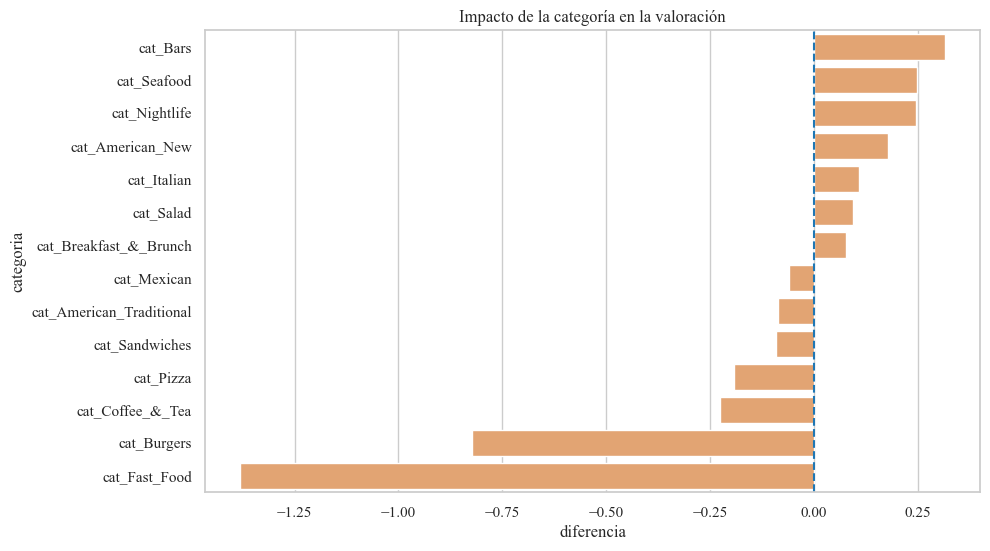

In [71]:
plt.figure(figsize=(10,6))
sns.barplot(data=results_cat_df, x="diferencia", y="categoria", color="#F4A261")
plt.axvline(0, linestyle="--")
plt.title("Impacto de la categoría en la valoración")
plt.show()

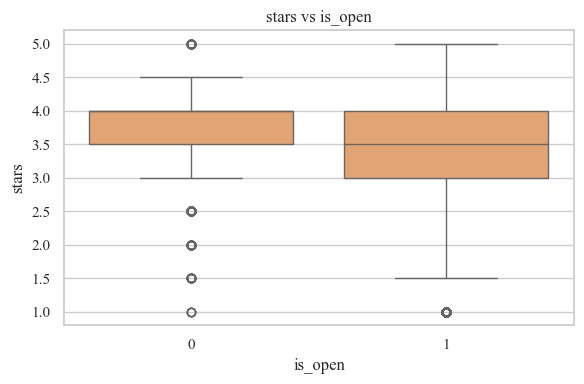

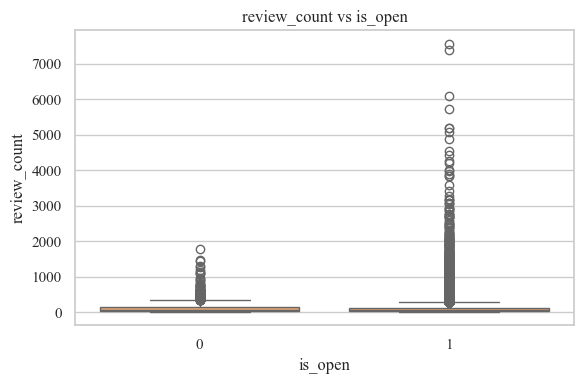

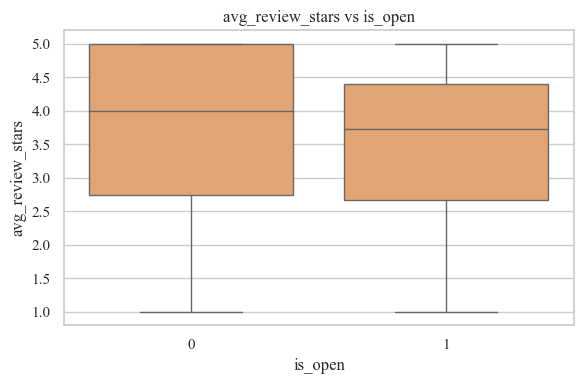

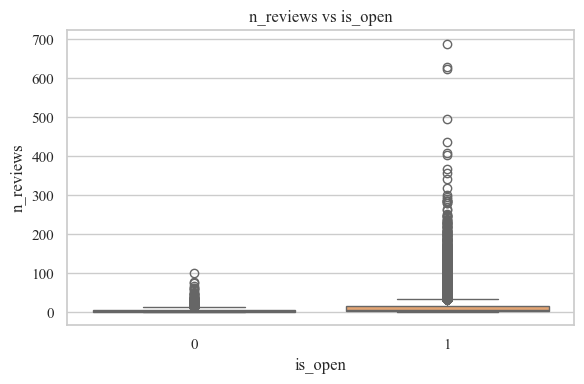

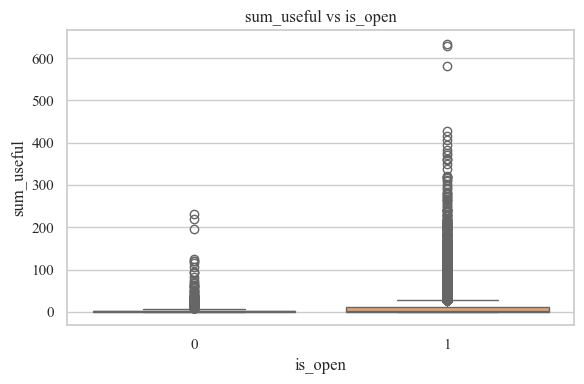

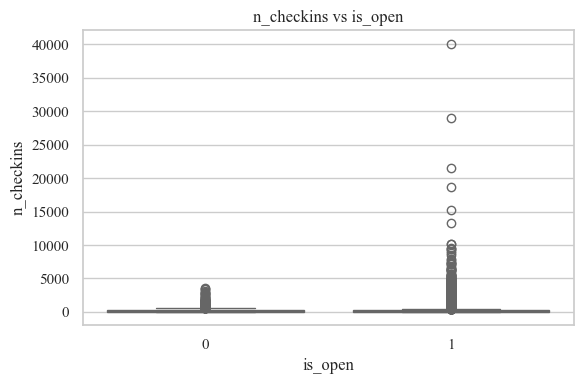

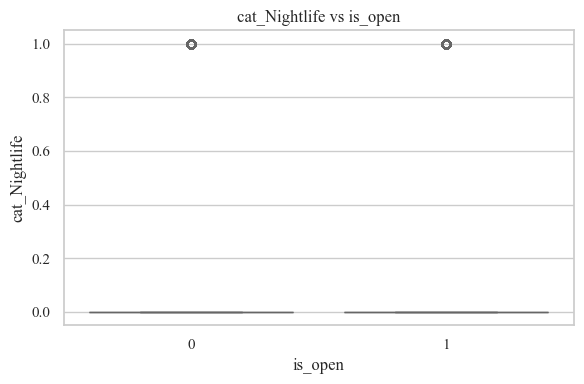

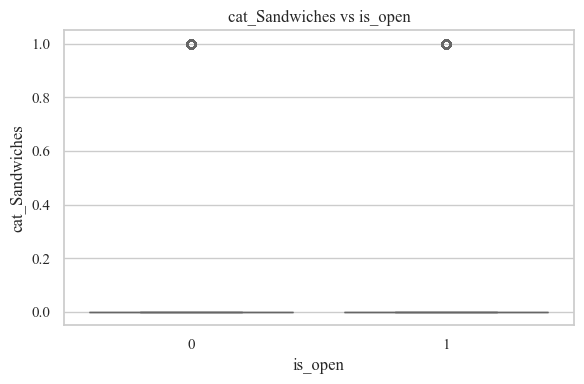

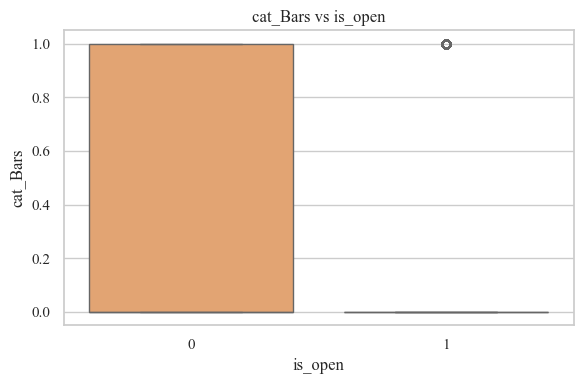

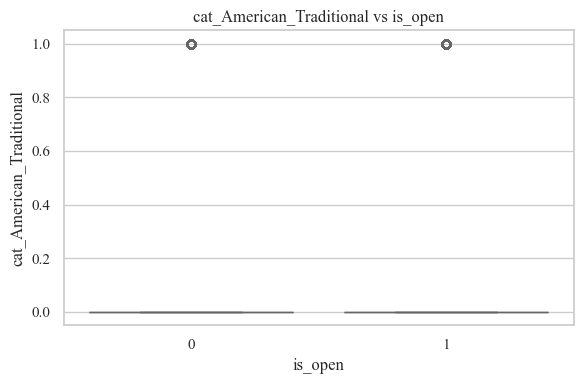

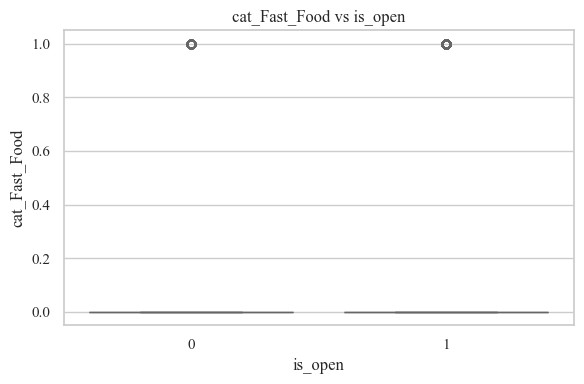

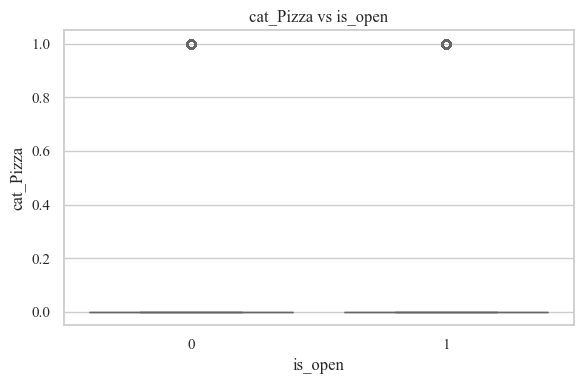

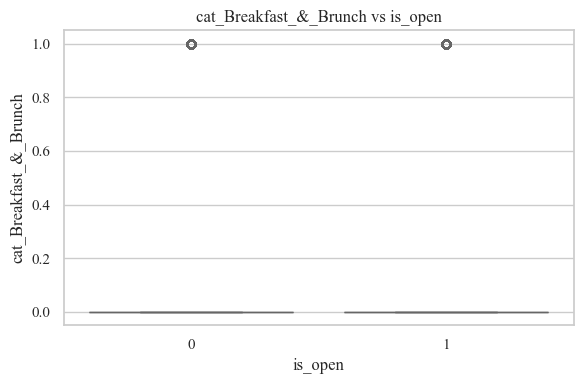

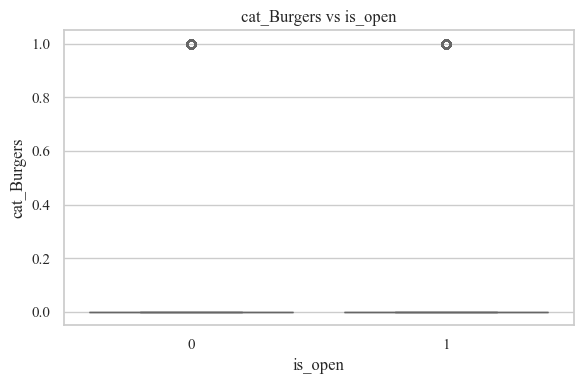

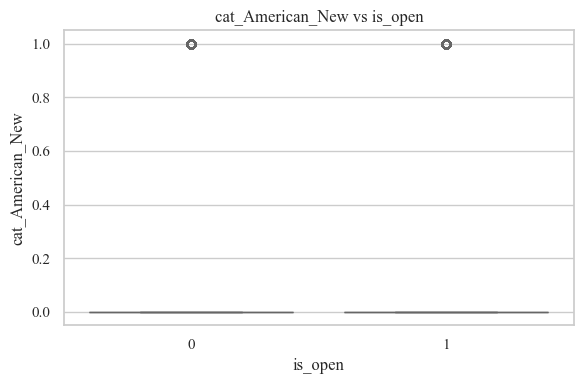

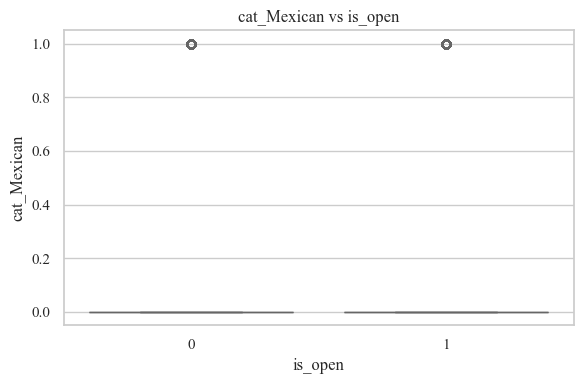

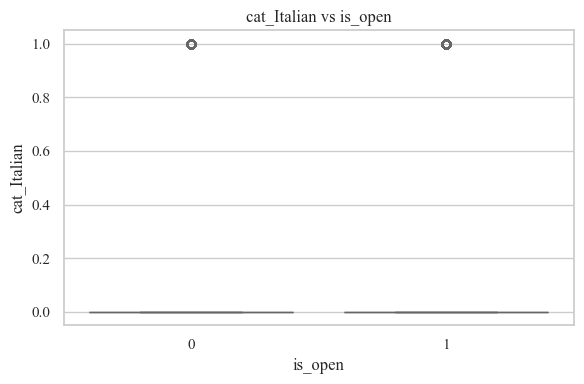

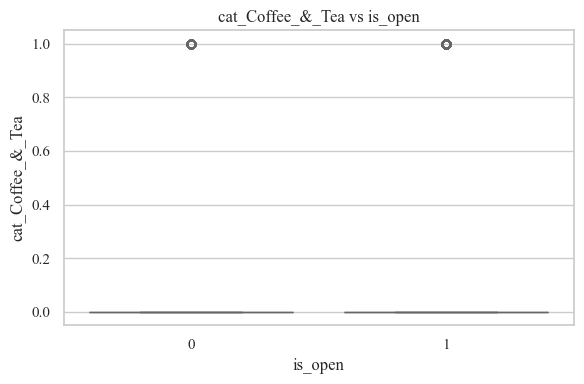

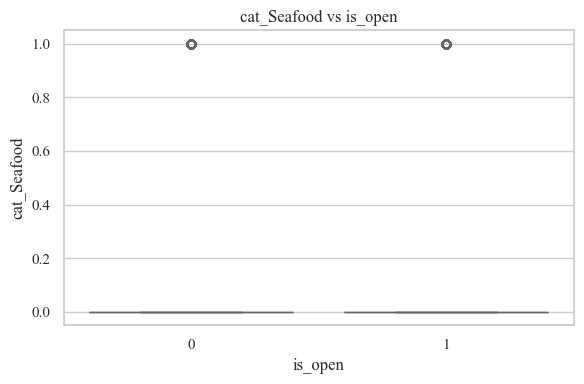

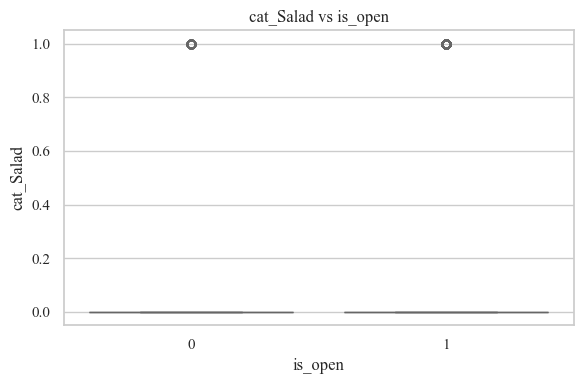

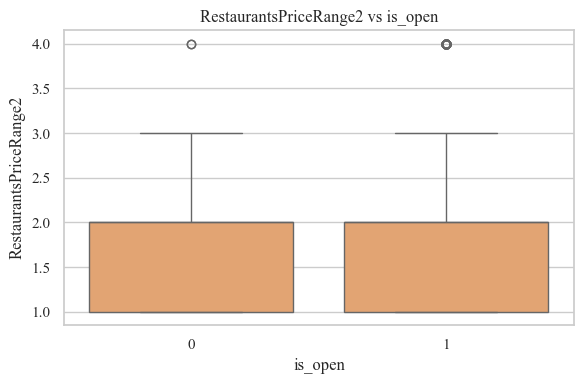

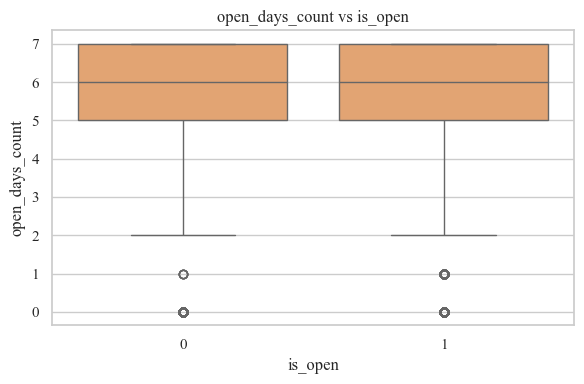

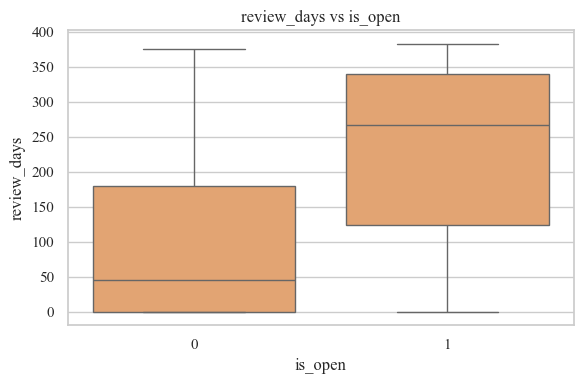

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = df_rest.select_dtypes(include=["int64", "float64"]).columns

# quitar variables que no quieres
num_cols = [col for col in num_cols if col not in ["latitude", "longitude", "is_open"]]

for col in num_cols:
    plt.figure(figsize=(6,4))
    
    sns.boxplot(
        data=df_rest,
        x="is_open",
        y=col,
        color="#F4A261"
    )
    
    plt.title(f"{col} vs is_open")
    plt.tight_layout()
    plt.show()

## Análisis de clientes
(para reglas de decisión) en otro notebook.

## PREPROCESO


### Holdout + pipelines de preproceso
Para evitar *dataleakage*. Todo lo que implique fit() se hace SOLO con X_train. El test solo se transforma con .transform()

In [73]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    FunctionTransformer
)
from sklearn.decomposition import PCA

#Copia del dataset
df = df_rest.copy()

#Definir variables objetivo
TARGET_REG = "avg_review_stars"
TARGET_CLF = "is_open"

y_reg = df[TARGET_REG].copy()
y_clf = df[TARGET_CLF].copy()


#Columnas a excluir antes del holdout
# Justificación:
# - business_id: identificador
# - name, address: alta cardinalidad y poco valor directo
# - attributes, hours: estructuras complejas / texto no tratado aquí
# - city: preferimos city_grouped para reducir cardinalidad
# - city_clean: redundante con city / city_grouped
# - first_review_x, last_review_x, first_review_y, last_review_y,
#   first_review, last_review: fechas crudas/duplicadas; nos quedamos con
#   variables derivadas como first_year, last_year, review_days
#
# NOTA:
# - 'categories' se excluye del bloque estructurado porque ya hay dummies
#   cat_* y además puede ir a un pipeline NLP aparte si quieres trabajar texto.
drop_cols_base = [
    TARGET_REG,
    TARGET_CLF,
    "business_id",
    "name",
    "address",
    "attributes",
    "hours",
    "city",
    "city_clean",
    "categories",
    "first_review_x",
    "last_review_x",
    "first_review_y",
    "last_review_y",
    "first_review",
    "last_review"
]

X = df.drop(columns=drop_cols_base, errors="ignore").copy()

#HOLDOUT
#Un único split, estratificado por la variable de clasificación
#para mantener el mismo train/test en ambos problemas
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X,
    y_reg,
    y_clf,
    test_size=0.20,
    random_state=42,
    stratify=y_clf
)

#Ajustes básicos
# Convertimos bool a int para tratarlos como variables numéricas binarias
for col in X_train.select_dtypes(include=["bool", "boolean"]).columns:
    X_train[col] = X_train[col].fillna(False).astype(int)
    X_test[col] = X_test[col].fillna(False).astype(int)

#DEFINICIÓN DE COLUMNAS NUMÉRICAS Y CATEGÓRICAS
#(solo usando X_train para evitar leakage)
#
num_cols = X_train.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

# =========================================================
# 7. DETECCIÓN DE COLUMNAS CON ALTA ASIMETRÍA PARA log1p
#    (solo en train)
# =========================================================
# Criterio:
# - skew > 1
# - valores no negativos
#
# Esto es coherente con el EDA: review_count, n_reviews, sum_useful,
# n_checkins, review_days suelen ser candidatas.
skew_train = X_train[num_cols].skew(numeric_only=True)
nonneg_train = (X_train[num_cols].min(numeric_only=True) >= 0)

log_cols = skew_train[(skew_train > 1) & (nonneg_train)].index.tolist()

# Quitamos variables binarias de log aunque cumplan el criterio
binary_num_cols = [
    c for c in num_cols
    if X_train[c].dropna().nunique() <= 2
]
log_cols = [c for c in log_cols if c not in binary_num_cols]

num_no_log_cols = [c for c in num_cols if c not in log_cols]

print("\nColumnas con log1p:", log_cols)
print("Numéricas sin log:", num_no_log_cols)
print("Binarias numéricas:", binary_num_cols)

#Eliminación manual de columnas
#review_days_group mejor como categórica si está en object,
# y las dummies cat_* o trayectoria_* ya quedan como numéricas binarias.
#stars tiene demasiada colinealidad conavg_review_stars.
cols_to_remove_manual = ["postal_code", "stars"]
X_train = X_train.drop(columns=cols_to_remove_manual, errors="ignore")
X_test = X_test.drop(columns=cols_to_remove_manual, errors="ignore")
num_cols = [c for c in num_cols if c not in cols_to_remove_manual]
cat_cols = [c for c in cat_cols if c not in cols_to_remove_manual]
log_cols = [c for c in log_cols if c not in cols_to_remove_manual]
num_no_log_cols = [c for c in num_no_log_cols if c not in cols_to_remove_manual]

#PIPELINES DE TRANSFORMACIÓN:

# ---------- Numéricas con log ----------
log_num_pipeline_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("scaler", StandardScaler())
])

# ---------- Numéricas sin log ----------
num_pipeline_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# ---------- Categóricas ----------
cat_pipeline_ohe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

#PREPROCESADOR GENERAL
#Para modelos lineales y basados en distancia(regresión lineal, logística, KNN, SVM, etc.)
preprocessor_general = ColumnTransformer(
    transformers=[
        ("log_num", log_num_pipeline_scaled, log_cols),
        ("num", num_pipeline_scaled, num_no_log_cols),
        ("cat", cat_pipeline_ohe, cat_cols)
    ],
    remainder="drop"
)

#PREPROCESADOR PARA ÁRBOL
log_num_pipeline_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("log1p", FunctionTransformer(np.log1p, validate=False))
])

num_pipeline_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

cat_pipeline_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("log_num", log_num_pipeline_tree, log_cols),
        ("num", num_pipeline_tree, num_no_log_cols),
        ("cat", cat_pipeline_tree, cat_cols)
    ],
    remainder="drop"
)

#PREPROCESADOR PARA PCA
#Aquí se usan únicamente numéricas + binarias ya presentes.
pca_num_cols = num_cols.copy()

preprocessor_pca = ColumnTransformer(
    transformers=[
        ("log_num", log_num_pipeline_scaled, [c for c in log_cols if c in pca_num_cols]),
        ("num", num_pipeline_scaled, [c for c in num_no_log_cols if c in pca_num_cols]),
    ],
    remainder="drop"
)

pca_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor_pca),
    ("pca", PCA(n_components=0.90, random_state=42))
])


#AJUSTE DE LOS PREPROCESADORES SOLO EN TRAIN
X_train_general = preprocessor_general.fit_transform(X_train)
X_test_general = preprocessor_general.transform(X_test)

X_train_tree = preprocessor_tree.fit_transform(X_train)
X_test_tree = preprocessor_tree.transform(X_test)

X_train_pca_ready = preprocessor_pca.fit_transform(X_train)
X_test_pca_ready = preprocessor_pca.transform(X_test)

X_train_pca = pca_pipeline.fit_transform(X_train)
X_test_pca = pca_pipeline.transform(X_test)


#Info de salida
print("\n--- Shapes ---")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nGeneral:")
print("Train:", X_train_general.shape)
print("Test :", X_test_general.shape)

print("\nTree:")
print("Train:", X_train_tree.shape)
print("Test :", X_test_tree.shape)

print("\nPCA ready (antes de PCA):")
print("Train:", X_train_pca_ready.shape)
print("Test :", X_test_pca_ready.shape)

print("\nPCA final:")
print("Train:", X_train_pca.shape)
print("Test :", X_test_pca.shape)

#Resumen de columnas usadas
preprocess_summary = {
    "num_cols": num_cols,
    "cat_cols": cat_cols,
    "log_cols": log_cols,
    "num_no_log_cols": num_no_log_cols,
    "binary_num_cols": binary_num_cols
}

preprocess_summary

Numéricas: ['latitude', 'longitude', 'stars', 'review_count', 'n_reviews', 'sum_useful', 'n_checkins', 'cat_Nightlife', 'cat_Sandwiches', 'cat_Bars', 'cat_American_Traditional', 'cat_Fast_Food', 'cat_Pizza', 'cat_Breakfast_&_Brunch', 'cat_Burgers', 'cat_American_New', 'cat_Mexican', 'cat_Italian', 'cat_Coffee_&_Tea', 'cat_Seafood', 'cat_Salad', 'BusinessAcceptsCreditCards', 'BikeParking', 'RestaurantsPriceRange2', 'open_days_count', 'open_weekend', 'open_7_days', 'first_year', 'last_year', 'review_days', 'trayectoria_trayectoria_baja', 'trayectoria_trayectoria_media_baja', 'trayectoria_trayectoria_media_alta', 'trayectoria_trayectoria_alta']
Categóricas: ['state', 'postal_code', 'city_grouped', 'review_days_group']

Columnas con log1p: ['review_count', 'n_reviews', 'sum_useful', 'n_checkins']
Numéricas sin log: ['latitude', 'longitude', 'stars', 'cat_Nightlife', 'cat_Sandwiches', 'cat_Bars', 'cat_American_Traditional', 'cat_Fast_Food', 'cat_Pizza', 'cat_Breakfast_&_Brunch', 'cat_Burger

{'num_cols': ['latitude',
  'longitude',
  'review_count',
  'n_reviews',
  'sum_useful',
  'n_checkins',
  'cat_Nightlife',
  'cat_Sandwiches',
  'cat_Bars',
  'cat_American_Traditional',
  'cat_Fast_Food',
  'cat_Pizza',
  'cat_Breakfast_&_Brunch',
  'cat_Burgers',
  'cat_American_New',
  'cat_Mexican',
  'cat_Italian',
  'cat_Coffee_&_Tea',
  'cat_Seafood',
  'cat_Salad',
  'BusinessAcceptsCreditCards',
  'BikeParking',
  'RestaurantsPriceRange2',
  'open_days_count',
  'open_weekend',
  'open_7_days',
  'first_year',
  'last_year',
  'review_days',
  'trayectoria_trayectoria_baja',
  'trayectoria_trayectoria_media_baja',
  'trayectoria_trayectoria_media_alta',
  'trayectoria_trayectoria_alta'],
 'cat_cols': ['state', 'city_grouped', 'review_days_group'],
 'log_cols': ['review_count', 'n_reviews', 'sum_useful', 'n_checkins'],
 'num_no_log_cols': ['latitude',
  'longitude',
  'cat_Nightlife',
  'cat_Sandwiches',
  'cat_Bars',
  'cat_American_Traditional',
  'cat_Fast_Food',
  'cat_Pi

In [74]:
bool_cols = X_train.select_dtypes(include=["bool", "boolean"]).columns

for col in bool_cols:
    print(col, X_train[col].isna().sum())

A continuación se crea la base preprocesada

In [75]:
#Base preprocesada
feature_names_general = preprocessor_general.get_feature_names_out()

X_train_base_df = pd.DataFrame(
    X_train_general.toarray() if hasattr(X_train_general, "toarray") else X_train_general,
    columns=feature_names_general,
    index=X_train.index
)

X_test_base_df = pd.DataFrame(
    X_test_general.toarray() if hasattr(X_test_general, "toarray") else X_test_general,
    columns=feature_names_general,
    index=X_test.index
)

print(X_train_base_df.shape, X_test_base_df.shape)
X_train_base_df.head()

(25458, 66) (6365, 66)


,log_num__review_count,log_num__n_reviews,log_num__sum_useful,log_num__n_checkins,num__latitude,num__longitude,num__cat_Nightlife,num__cat_Sandwiches,num__cat_Bars,num__cat_American_Traditional,...,cat__city_grouped_reno,cat__city_grouped_saint louis,cat__city_grouped_santa barbara,cat__city_grouped_tampa,cat__city_grouped_tucson,cat__city_grouped_wilmington,cat__review_days_group_trayectoria_alta,cat__review_days_group_trayectoria_baja,cat__review_days_group_trayectoria_media_alta,cat__review_days_group_trayectoria_media_baja
3772,-0.336006,-1.345111,-1.117791,0.503743,0.541966,0.931880,-0.462435,-0.453775,-0.536567,-0.445758,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
12066,0.364131,1.645757,1.089416,0.098361,0.339491,-0.188339,2.162465,2.203736,1.863700,-0.445758,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1670,-0.742948,-1.345111,-1.117791,-1.392658,-1.453650,0.369969,-0.462435,-0.453775,-0.536567,-0.445758,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
17588,0.086098,0.316749,0.088674,0.010449,0.561174,0.936556,-0.462435,-0.453775,1.863700,-0.445758,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
7758,1.304090,-0.451872,0.744942,1.073276,0.574498,0.920624,-0.462435,-0.453775,-0.536567,2.243368,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [76]:
# Guardar a CSV
X_train_base_df.to_csv("X_train_preprocesado.csv", index=True)
X_test_base_df.to_csv("X_test_preprocesado.csv", index=True)

In [77]:
y_train_base = pd.concat([y_reg_train, y_clf_train], axis=1)
y_test_base = pd.concat([y_reg_test, y_clf_test], axis=1)

y_train_base.to_csv("y_train.csv", index=True)
y_test_base.to_csv("y_test.csv", index=True)

In [78]:
#Guardar ids
# Guardar IDs de train y test
train_ids = df.loc[X_train.index, ["business_id"]]
test_ids = df.loc[X_test.index, ["business_id"]]

train_ids.to_csv("train_business_ids.csv", index=False)
test_ids.to_csv("test_business_ids.csv", index=False)

## ANÁLISIS DE COMPONENTES PRINCIPALES (PCA)
Se utilizan los conjuntos: X_train_pca y X_test_pca
Como se habían creado variables a partir de las originales, el PCA elimina la redundancia.

In [79]:
# Extraer el PCA entrenado desde el pipeline
pca_model = pca_pipeline.named_steps["pca"]

# Nombres consistentes de componentes
pc_names = [f"PC{i+1}" for i in range(X_train_pca.shape[1])]

X_train_pca_df = pd.DataFrame(
    X_train_pca,
    columns=pc_names,
    index=X_train.index
)

X_test_pca_df = pd.DataFrame(
    X_test_pca,
    columns=pc_names,
    index=X_test.index
)

# Varianza explicada
explained_var = pca_model.explained_variance_ratio_
explained_var_cum = np.cumsum(explained_var)

pca_var_df = pd.DataFrame({
    "Componente": pc_names,
    "Varianza explicada": explained_var,
    "Varianza acumulada": explained_var_cum
})

pca_var_df

,Componente,Varianza explicada,Varianza acumulada
0,PC1,0.168432,0.168432
1,PC2,0.071495,0.239927
2,PC3,0.063186,0.303113
3,PC4,0.058582,0.361696
4,PC5,0.050771,0.412466
5,PC6,0.046675,0.459141
6,PC7,0.041482,0.500624
7,PC8,0.038399,0.539022
8,PC9,0.037593,0.576616
9,PC10,0.036961,0.613577


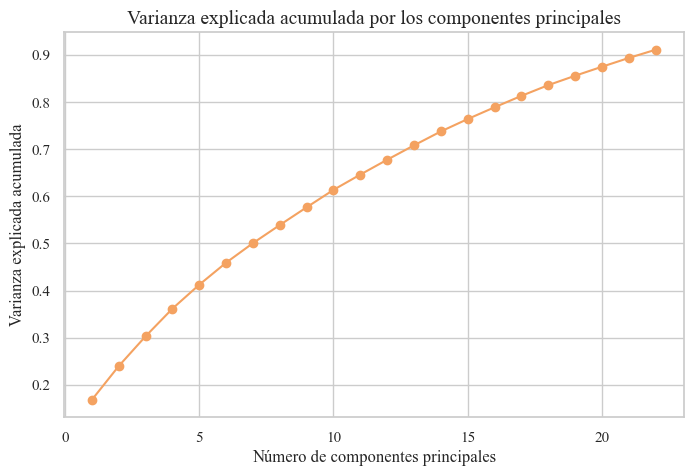

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_context("notebook")
plt.rcParams["font.family"] = "Times New Roman"

plt.figure(figsize=(8,5))

plt.plot(range(1, len(explained_var_cum)+1), explained_var_cum, marker="o", color="#F4A261")

plt.title("Varianza explicada acumulada por los componentes principales", fontsize=14)
plt.xlabel("Número de componentes principales", fontsize=12)
plt.ylabel("Varianza explicada acumulada", fontsize=12)

plt.show()

Estructura compleja y multidimensional del comportamiento de los restaurantes
- PCA no reduce significativamente la dimensionalidad
- Se mantiene un número elevado de componentes para conservar la varianza
- Se prioriza trabajar con variables originales para clustering

Dado que el PCA requiere un número relativamente alto de componentes para mantener la varianza, se opta por realizar el clustering sobre las variables originales preprocesadas, favoreciendo la interpretabilidad de los resultados.

## Clustering

### KMeans

- Selección del número de clústers: Método del codo y de la silueta.

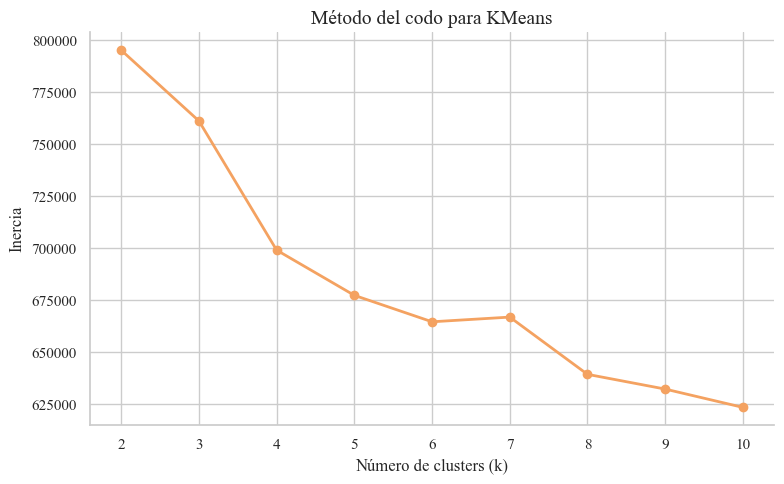

In [81]:
from sklearn.cluster import KMeans

inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_train_base_df)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    inertia,
    marker='o',
    color="#F4A261",
    linewidth=2
)

plt.title("Método del codo para KMeans", fontsize=14)
plt.xlabel("Número de clusters (k)", fontsize=12)
plt.ylabel("Inercia", fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

In [82]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_train_base_df)
    score = silhouette_score(X_train_base_df, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    silhouette_scores,
    marker='o',
    color="#F4A261",
    linewidth=2
)

plt.title("Coeficiente de silueta según número de clusters", fontsize=14)
plt.xlabel("Número de clusters (k)", fontsize=12)
plt.ylabel("Coeficiente de silueta", fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

In [ ]:
# Clustering
from sklearn.cluster import KMeans
import pandas as pd

k_opt = 4  # elegido según codo + silueta

kmeans = KMeans(n_clusters=k_opt, random_state=42)

clusters_train = kmeans.fit_predict(X_train_base_df)
clusters_test = kmeans.predict(X_test_base_df)

# Añadir cluster al dataset de análisis
X_train_cluster = X_train_base_df.copy()
X_test_cluster = X_test_base_df.copy()

X_train_cluster["cluster"] = clusters_train
X_test_cluster["cluster"] = clusters_test

In [ ]:
#Ver si están balanceados los cluster

# Frecuencia absoluta
cluster_counts = X_train_cluster["cluster"].value_counts().sort_index()

# Frecuencia relativa
cluster_perc = X_train_cluster["cluster"].value_counts(normalize=True).sort_index() * 100

cluster_balance = pd.DataFrame({
    "n_restaurantes": cluster_counts,
    "porcentaje": cluster_perc.round(2)
})

cluster_balance

,n_restaurantes,porcentaje
cluster,,
0,6385,25.08
1,6334,24.88
2,6328,24.86
3,6411,25.18


In [ ]:
#Interpretar clústers (SOBRE DATASET ORIGINAL, NO TRANSFORMADO ES MÁS INTERPRETABLE)
X_train_interpret = X_train.copy()
X_train_interpret["cluster"] = kmeans.labels_

cluster_profile = X_train_interpret.groupby("cluster")[num_cols].mean().round(2)
cluster_profile

,latitude,longitude,review_count,n_reviews,sum_useful,n_checkins,cat_Nightlife,cat_Sandwiches,cat_Bars,cat_American_Traditional,...,open_days_count,open_weekend,open_7_days,first_year,last_year,review_days,trayectoria_trayectoria_baja,trayectoria_trayectoria_media_baja,trayectoria_trayectoria_media_alta,trayectoria_trayectoria_alta
cluster,,,,,,,,,,,,,,,,,,,,,
0,36.32,-87.36,104.65,11.87,9.66,200.17,0.19,0.16,0.24,0.18,...,5.32,0.74,0.47,2021.00,2021.30,303.80,0.0,0.00,1.0,0.00
1,38.07,-87.28,35.23,2.07,1.73,70.23,0.11,0.19,0.14,0.13,...,5.30,0.74,0.47,2021.03,2021.08,25.11,1.0,0.00,0.0,0.00
2,35.31,-89.55,275.08,34.08,28.02,488.04,0.27,0.15,0.33,0.20,...,5.34,0.74,0.47,2021.00,2021.81,360.32,0.0,0.01,0.0,0.99
3,37.03,-86.63,55.63,6.27,5.13,106.96,0.14,0.19,0.18,0.15,...,5.37,0.75,0.48,2021.00,2021.14,196.13,0.0,0.99,0.0,0.01


In [ ]:
cluster_profile.T

cluster,0,1,2,3
latitude,36.32,38.07,35.31,37.03
longitude,-87.36,-87.28,-89.55,-86.63
review_count,104.65,35.23,275.08,55.63
n_reviews,11.87,2.07,34.08,6.27
sum_useful,9.66,1.73,28.02,5.13
n_checkins,200.17,70.23,488.04,106.96
cat_Nightlife,0.19,0.11,0.27,0.14
cat_Sandwiches,0.16,0.19,0.15,0.19
cat_Bars,0.24,0.14,0.33,0.18
cat_American_Traditional,0.18,0.13,0.20,0.15


Guardar un CSV con los ids:

In [ ]:
X_train_cluster["business_id"] = train_ids["business_id"].values
X_test_cluster["business_id"] = test_ids["business_id"].values

In [ ]:
X_train_cluster.to_csv("X_train_cluster.csv", index=False)
X_test_cluster.to_csv("X_test_cluster.csv", index=False)

In [ ]:
# Crear DataFrames con identificador
y_reg_df = pd.DataFrame({
    "business_id": df["business_id"],
    "avg_review_stars": y_reg
})

y_clf_df = pd.DataFrame({
    "business_id": df["business_id"],
    "is_open": y_clf
})

# Guardar
y_reg_df.to_csv("y_reg.csv", index=False)
y_clf_df.to_csv("y_clf.csv", index=False)

In [ ]:
X_train_cluster.columns

Index(['log_num__review_count', 'log_num__n_reviews', 'log_num__sum_useful',
       'log_num__n_checkins', 'num__latitude', 'num__longitude',
       'num__cat_Nightlife', 'num__cat_Sandwiches', 'num__cat_Bars',
       'num__cat_American_Traditional', 'num__cat_Fast_Food', 'num__cat_Pizza',
       'num__cat_Breakfast_&_Brunch', 'num__cat_Burgers',
       'num__cat_American_New', 'num__cat_Mexican', 'num__cat_Italian',
       'num__cat_Coffee_&_Tea', 'num__cat_Seafood', 'num__cat_Salad',
       'num__BusinessAcceptsCreditCards', 'num__BikeParking',
       'num__RestaurantsPriceRange2', 'num__open_days_count',
       'num__open_weekend', 'num__open_7_days', 'num__first_year',
       'num__last_year', 'num__review_days',
       'num__trayectoria_trayectoria_baja',
       'num__trayectoria_trayectoria_media_baja',
       'num__trayectoria_trayectoria_media_alta',
       'num__trayectoria_trayectoria_alta', 'cat__state_AB', 'cat__state_AZ',
       'cat__state_CA', 'cat__state_DE', 'cat__stat